# Chunking Metrics Evaluation
Runs `cluster_break_rate`, `edge_cut_rate`, and `entity_concentration` from `metrics.py` across all chunk configurations, paired with their coreference clusters.

In [7]:
import json
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('.').resolve()))
from metrics import cluster_break_rate, edge_cut_rate, entity_concentration

pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 15,
})

METRICS = ['cluster_break_rate', 'edge_cut_rate', 'entity_concentration']
METHOD_SHORT   = {'most_recent': 'mr', 'most_recent_low_accessible': 'mrla'}
SENT_SHORT     = {'full_sentence_included': 'si', 'full_sentence_excluded': 'se'}
W_SHORT        = {'weighted': 'w', 'unweighted': 'u'}
STRATEGY_SHORT = {'conservative': 'c', 'liberal': 'l'}


def mention_char_to_chunk(mention_start, boundaries):
    for i, boundary in enumerate(boundaries[1:], 1):
        if mention_start < boundary:
            return i - 1
    return len(boundaries) - 2


def build_mention_chunks(chains, chunk_texts):
    boundaries = [0]
    for text in chunk_texts:
        boundaries.append(boundaries[-1] + len(text))
    mention_chunks = [
        [mention_char_to_chunk(m[0], boundaries) for m in chain]
        for chain in chains
    ]
    return mention_chunks, len(chunk_texts)


def load_metrics_for_doc(domain, source_file):
    source_stem = Path(source_file).stem
    cluster_path = Path('clusters') / domain / f'{source_stem}.json'
    if not cluster_path.exists():
        print(f'WARNING: cluster file not found: {cluster_path}')
        return pd.DataFrame()
    with open(cluster_path) as f:
        chains = json.load(f)
    records = []
    for chunks_path in sorted((Path('chunks') / domain / source_file).rglob('chunks_output.json')):
        parts = chunks_path.parts
        with open(chunks_path) as f:
            data = json.load(f)
        mention_chunks, total_chunks = build_mention_chunks(chains, data['chunks'])
        records.append({
            'method':     parts[3],
            'sent_incl':  parts[4],
            'weighted':   parts[5],
            'strategy':   parts[6],
            'n_chunks':   data['metadata']['total_chunks_generated'],
            'n_chains':   len(chains),
            'cluster_break_rate':   round(cluster_break_rate(mention_chunks), 4),
            'edge_cut_rate':        round(edge_cut_rate(mention_chunks), 4),
            'entity_concentration': round(entity_concentration(mention_chunks, total_chunks), 4),
        })
    return pd.DataFrame(records)


def _config_label(parts):
    return (
        f"{METHOD_SHORT.get(parts[3], parts[3])}\n"
        f"{SENT_SHORT.get(parts[4], parts[4])}\n"
        f"{W_SHORT.get(parts[5], parts[5])}\n"
        f"{STRATEGY_SHORT.get(parts[6], parts[6])}"
    )


def plot_histograms(df, title):
    if df.empty:
        print(f'No data for {title}')
        return
    labels = [
        f"{METHOD_SHORT.get(r.method, r.method)}\n"
        f"{SENT_SHORT.get(r.sent_incl, r.sent_incl)}\n"
        f"{W_SHORT.get(r.weighted, r.weighted)}\n"
        f"{STRATEGY_SHORT.get(r.strategy, r.strategy)}"
        for r in df.itertuples()
    ]
    x = range(len(labels))
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(title, fontweight='bold')
    for ax, metric in zip(axes, METRICS):
        ax.bar(x, df[metric], color='steelblue', edgecolor='black')
        ax.set_xticks(list(x))
        ax.set_xticklabels(labels, fontsize=9)
        ax.set_title(metric.replace('_', ' ').title())
        ax.set_ylabel('Value')
        mean_val = df[metric].mean()
        ax.axhline(mean_val, color='red', linestyle='--', linewidth=1.5,
                   label=f'mean={mean_val:.3f}')
        ax.legend()
    plt.tight_layout()
    plt.show()


def plot_chunk_lengths(domain, source_file):
    all_paths = sorted((Path('chunks') / domain / source_file).rglob('chunks_output.json'))
    if not all_paths:
        print('No chunk files found.')
        return
    ncols = 4
    nrows = (len(all_paths) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
    fig.suptitle(f'Chunk Length Distribution - {source_file}', fontweight='bold')
    axes = axes.flatten()
    for i, chunks_path in enumerate(all_paths):
        parts = chunks_path.parts
        with open(chunks_path) as f:
            data = json.load(f)
        lengths = [len(c) for c in data['chunks']]
        axes[i].hist(lengths, bins=10, color='coral', edgecolor='black')
        axes[i].set_title(_config_label(parts), fontsize=10)
        axes[i].set_xlabel('Chars')
        axes[i].set_ylabel('Count')
    for j in range(len(all_paths), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()


def annotate_document(domain, source_file, config_index=0):
    source_stem = Path(source_file).stem
    doc_path    = Path('documents') / 'loong_docs' / domain / source_file
    cluster_path = Path('clusters') / domain / f'{source_stem}.json'
    all_paths = sorted((Path('chunks') / domain / source_file).rglob('chunks_output.json'))
    if not doc_path.exists():
        print(f'WARNING: source document not found: {doc_path}')
        return
    if not cluster_path.exists():
        print(f'WARNING: cluster file not found: {cluster_path}')
        return
    if not all_paths:
        print('No chunk files found.')
        return

    orig_text = doc_path.read_text(encoding='utf-8')

    chunks_path = all_paths[config_index]
    parts = chunks_path.parts
    config_label = (
        f"{METHOD_SHORT.get(parts[3], parts[3])} / "
        f"{SENT_SHORT.get(parts[4], parts[4])} / "
        f"{W_SHORT.get(parts[5], parts[5])} / "
        f"{STRATEGY_SHORT.get(parts[6], parts[6])}"
    )
    with open(cluster_path) as f:
        chains = json.load(f)
    with open(chunks_path) as f:
        data = json.load(f)

    chunk_texts = data['chunks']

    # Find each chunk's true start offset in the original document
    chunk_offsets = []
    search_from = 0
    for chunk_text in chunk_texts:
        anchor = chunk_text[:60]
        idx = orig_text.find(anchor, search_from)
        if idx == -1:
            idx = orig_text.find(anchor)  # fallback: search from beginning
        chunk_offsets.append(idx)
        if idx != -1:
            search_from = idx + len(chunk_text)

    print(f'Document : {source_file}')
    print(f'Config   : {config_label}')
    print(f'Chains   : {len(chains)}   Chunks: {len(chunk_texts)}')
    print()

    for chunk_idx, chunk_text in enumerate(chunk_texts):
        chunk_start = chunk_offsets[chunk_idx]
        if chunk_start == -1:
            print(f'  CHUNK {chunk_idx + 1}: could not locate in original, skipping annotation')
            print(chunk_text)
            print()
            continue
        chunk_end = chunk_start + len(chunk_text)

        # Collect all mention spans whose start falls within this chunk
        spans = []
        for chain_idx, chain in enumerate(chains):
            for mention in chain:
                m_start, m_end = mention[0], mention[1]
                if chunk_start <= m_start < chunk_end:
                    local_start = m_start - chunk_start
                    local_end   = min(m_end, chunk_end) - chunk_start
                    spans.append((local_start, local_end, chain_idx))

        # Insert markers in reverse order so earlier offsets stay valid
        spans.sort(key=lambda s: s[0], reverse=True)
        annotated = chunk_text
        for local_start, local_end, chain_idx in spans:
            annotated = (
                annotated[:local_start]
                + f'[E{chain_idx}|'
                + annotated[local_start:local_end]
                + ']'
                + annotated[local_end:]
            )

        print('=' * 70)
        print(f'  CHUNK {chunk_idx + 1} of {len(chunk_texts)}')
        if spans:
            from collections import Counter
            counts = Counter(s[2] for s in spans)
            counts_str = '  '.join(f'E{cid}: {cnt}' for cid, cnt in sorted(counts.items()))
            print(f'  Entities flagged: {counts_str}')
        print('=' * 70)
        print(annotated)
        print()


def load_baseline_metrics_for_doc(domain, source_file):
    source_stem = Path(source_file).stem
    cluster_path = Path('clusters') / domain / f'{source_stem}.json'
    chunks_path  = Path('chunks_baseline') / domain / source_file / 'chunks_output.json'

    if not cluster_path.exists():
        print(f'WARNING: cluster file not found: {cluster_path}')
        return pd.DataFrame()
    if not chunks_path.exists():
        print(f'WARNING: baseline chunks not found: {chunks_path}')
        print('Run generate_baseline_chunks.py first.')
        return pd.DataFrame()

    with open(cluster_path) as f:
        chains = json.load(f)
    with open(chunks_path) as f:
        data = json.load(f)

    mention_chunks, total_chunks = build_mention_chunks(chains, data['chunks'])
    row = {
        'method':                'recursive_character',
        'chunk_size_chars':      data['metadata']['chunk_size_chars'],
        'chunk_overlap_chars':   data['metadata']['chunk_overlap_chars'],
        'n_chunks':              data['metadata']['total_chunks_generated'],
        'n_chains':              len(chains),
        'cluster_break_rate':    round(cluster_break_rate(mention_chunks), 4),
        'edge_cut_rate':         round(edge_cut_rate(mention_chunks), 4),
        'entity_concentration':  round(entity_concentration(mention_chunks, total_chunks), 4),
    }
    return pd.DataFrame([row])


def plot_baseline_vs_coref(baseline_df, coref_df, title):
    """Side-by-side bar chart comparing baseline vs. mean of all coreference configs."""
    if baseline_df.empty or coref_df.empty:
        print('Missing data, skipping comparison plot.')
        return

    baseline_vals = [baseline_df.iloc[0][m] for m in METRICS]
    coref_means   = [coref_df[m].mean() for m in METRICS]

    x = range(len(METRICS))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar([i - width/2 for i in x], baseline_vals, width, label='Baseline (static 300-char)', color='coral',    edgecolor='black')
    ax.bar([i + width/2 for i in x], coref_means,   width, label='Coref mean (all configs)',  color='steelblue', edgecolor='black')
    ax.set_xticks(list(x))
    ax.set_xticklabels([m.replace('_', ' ').title() for m in METRICS])
    ax.set_title(f'Baseline vs. Coreference Chunking — {title}', fontweight='bold')
    ax.set_ylabel('Value')
    ax.legend()
    plt.tight_layout()
    plt.show()


---
## Financial Documents

,method,sent_incl,weighted,strategy,n_chunks,n_chains,cluster_break_rate,edge_cut_rate,entity_concentration
0,most_recent,full_sentence_excluded,unweighted,conservative,51,249,0.2972,0.5298,0.3919
1,most_recent,full_sentence_excluded,unweighted,liberal,84,249,0.3373,0.5847,0.4902
2,most_recent,full_sentence_excluded,weighted,conservative,52,249,0.2892,0.5475,0.3832
3,most_recent,full_sentence_excluded,weighted,liberal,86,249,0.3213,0.5782,0.4899
4,most_recent,full_sentence_included,unweighted,conservative,50,249,0.2811,0.5363,0.3773
5,most_recent,full_sentence_included,unweighted,liberal,79,249,0.3333,0.5726,0.4812
6,most_recent,full_sentence_included,weighted,conservative,49,249,0.3133,0.5475,0.3849
7,most_recent,full_sentence_included,weighted,liberal,80,249,0.3454,0.5652,0.4939
8,most_recent_low_accessible,full_sentence_excluded,unweighted,conservative,50,249,0.3414,0.5531,0.3682
9,most_recent_low_accessible,full_sentence_excluded,unweighted,liberal,80,249,0.4016,0.6034,0.4218


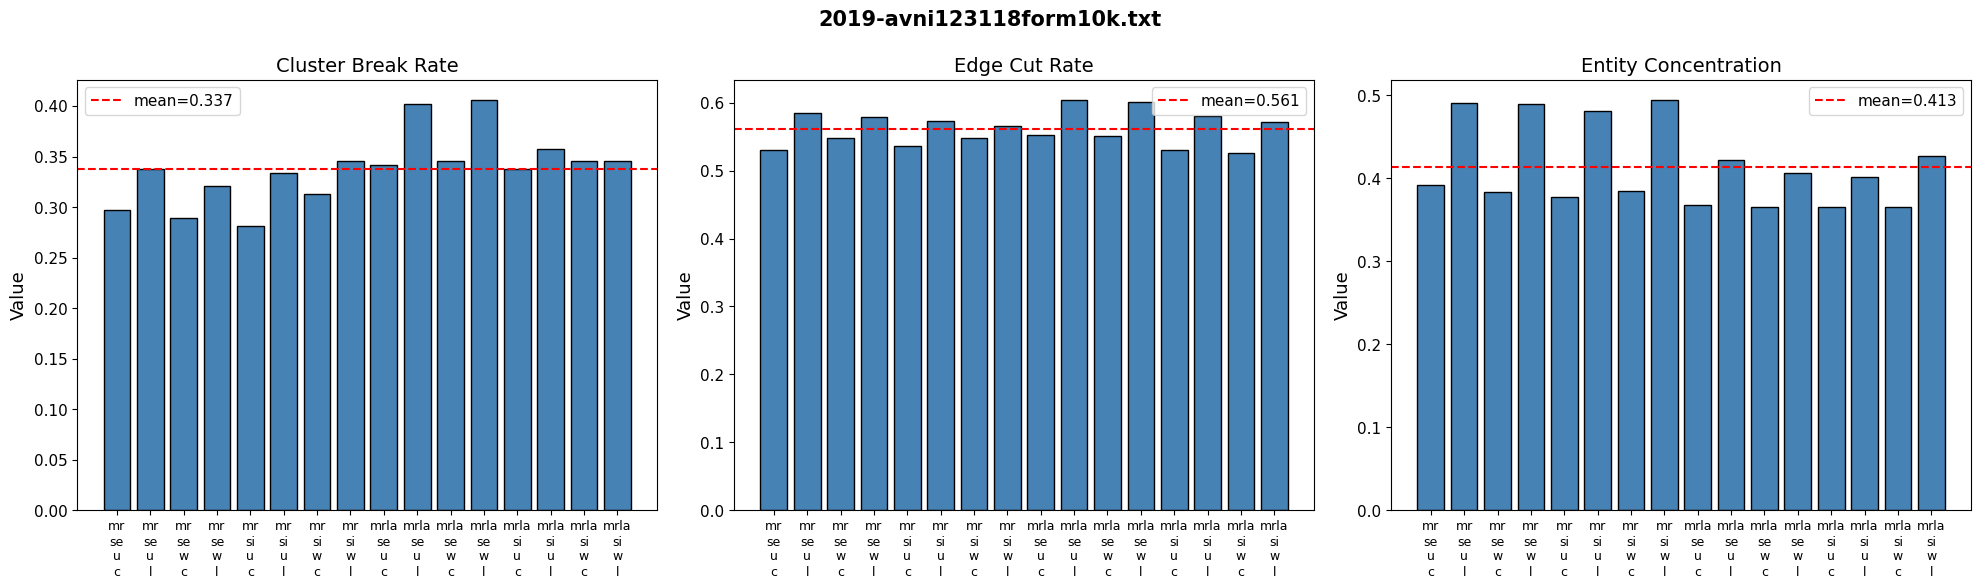

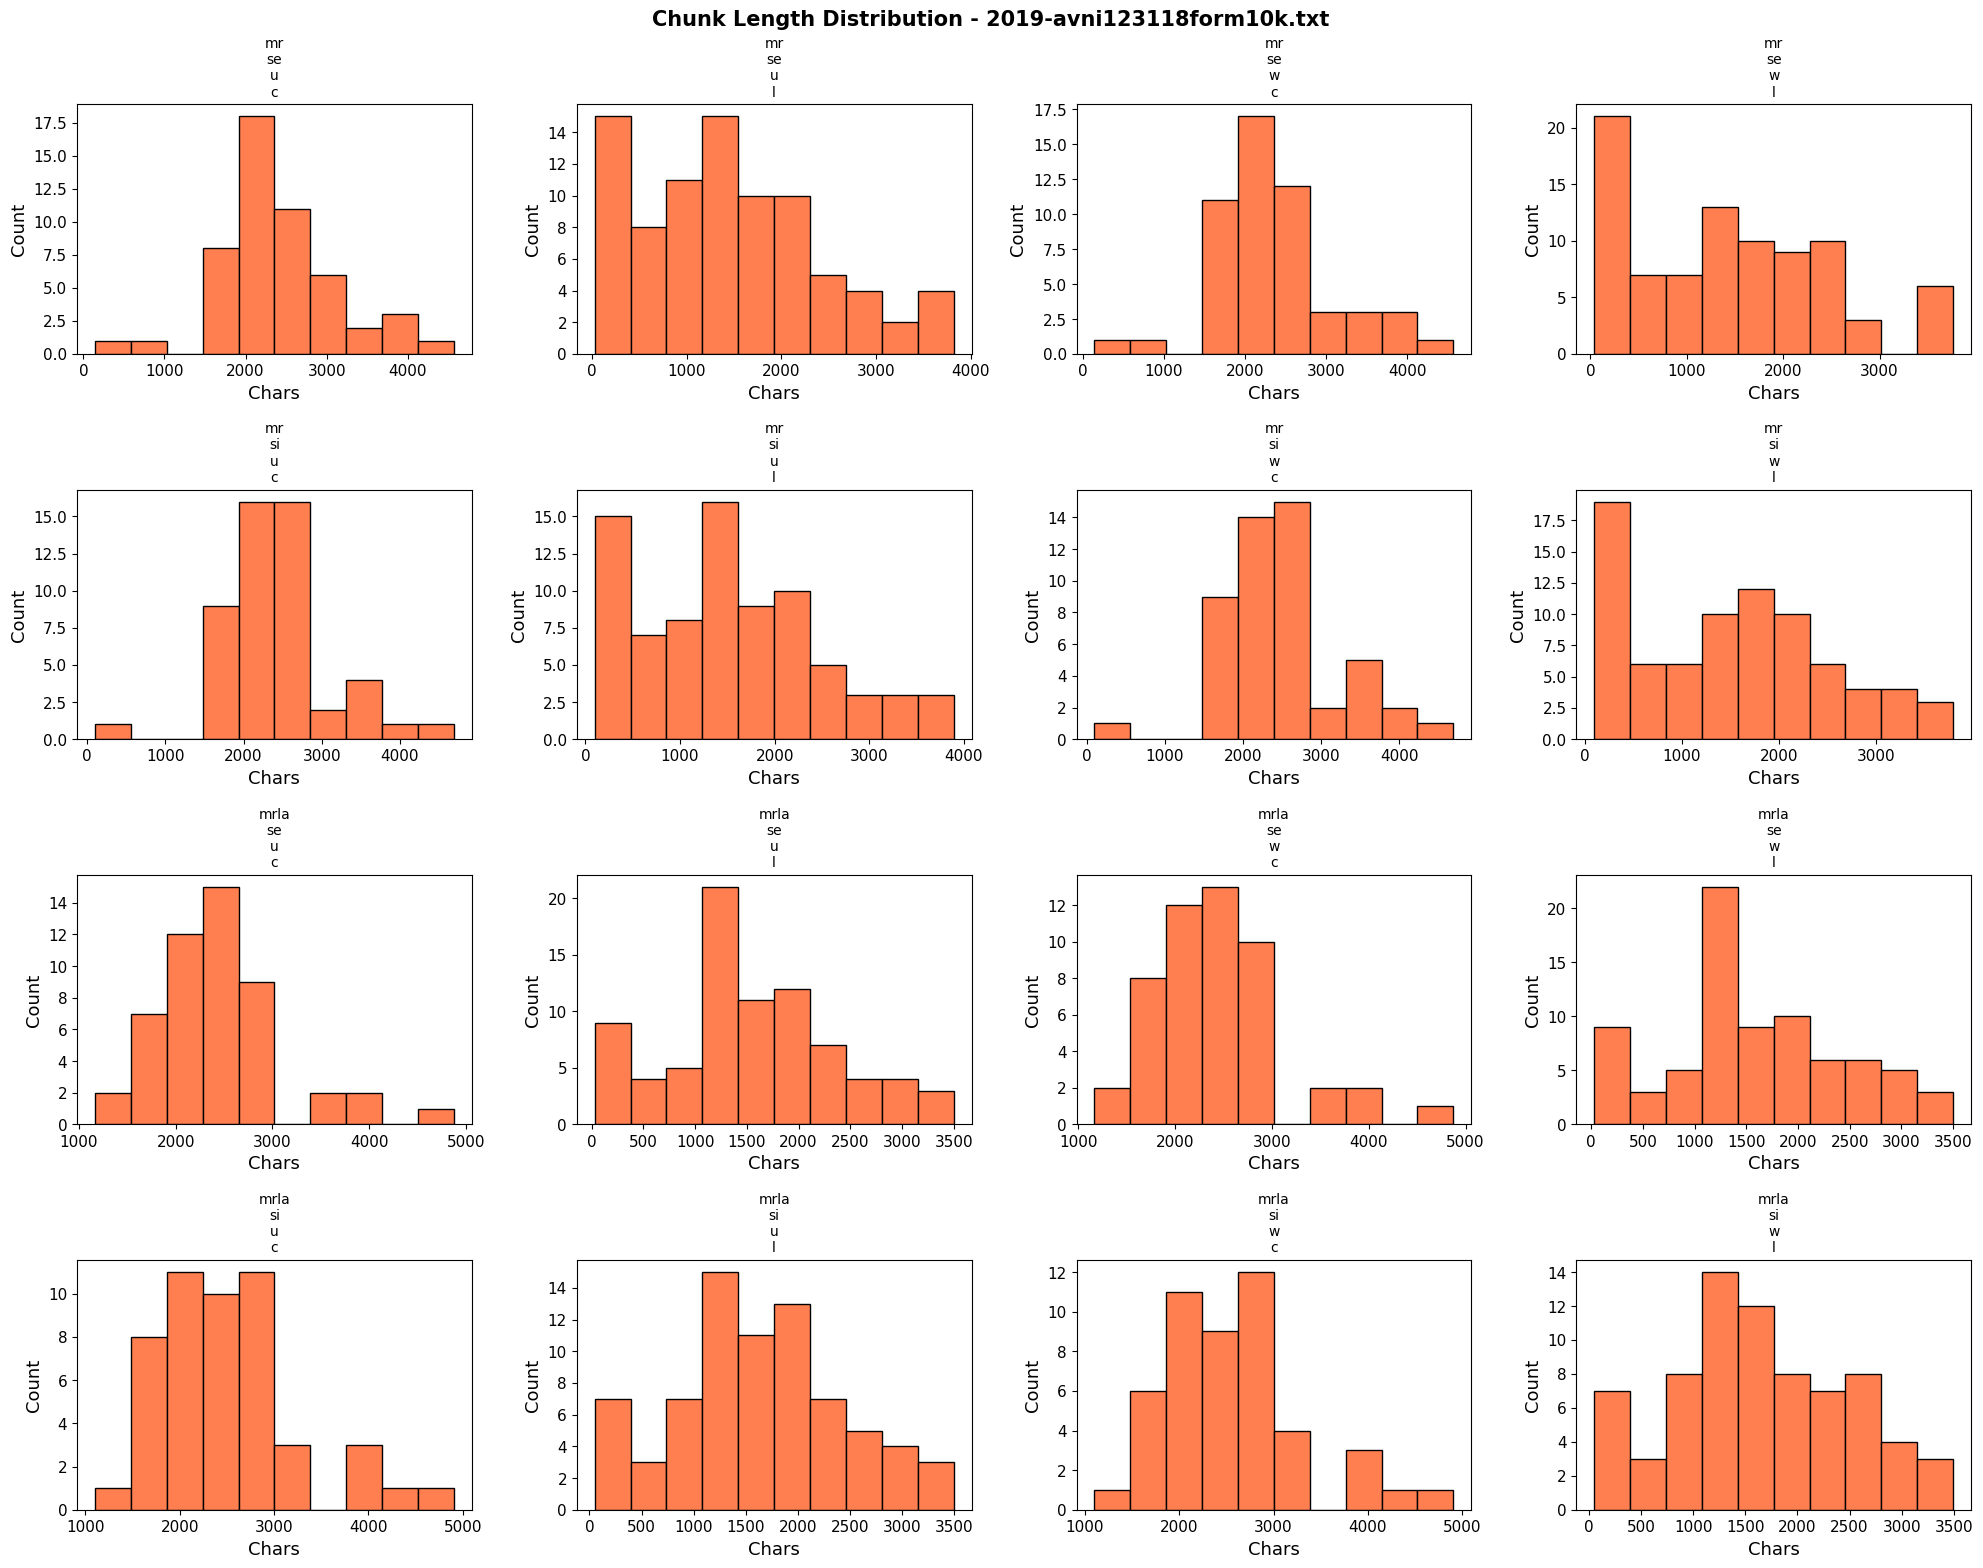

Document : 2019-avni123118form10k.txt
Config   : mr / se / u / c
Chains   : 249   Chunks: 51

  CHUNK 1 of 51
  Entities flagged: E0: 2  E1: 2  E2: 5  E3: 2  E4: 2  E18: 1  E19: 1
10-K 1 avni123118form10k.htm FORM 10-K 
UNITED STATES
SECURITIES AND EXCHANGE COMMISSION
Washington, D.C. 20549 
FORM 10-K
(Mark One)
☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(D) OF [E0|THE SECURITIES EXCHANGE ACT OF 1934]
For the fiscal year ended December 31, 2018.
☐ TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(D) OF [E0|THE SECURITIES EXCHANGE ACT OF 1934]
For the transition period from __ to __.
Commission file number: 0-30695
[E1|ARVANA INC.]
(Exact name of registrant as specified in [E1|its] charter)
                               [E18|Nevada]                                                            87-0618509
   (State or other jurisdiction of incorporation or organization)                   (I.R.S. Employer Identification No.)
 
299 S. Main Street, 13th Floor, Salt Lake City, [E19|Utah] 84111
(

In [8]:
_df = load_metrics_for_doc('financial', '2019-avni123118form10k.txt')
display(_df)
plot_histograms(_df, '2019-avni123118form10k.txt')
plot_chunk_lengths('financial', '2019-avni123118form10k.txt')
annotate_document('financial', '2019-avni123118form10k.txt')

,method,sent_incl,weighted,strategy,n_chunks,n_chains,cluster_break_rate,edge_cut_rate,entity_concentration
0,most_recent,full_sentence_excluded,unweighted,conservative,51,249,0.3092,0.5357,0.3601
1,most_recent,full_sentence_excluded,unweighted,liberal,88,249,0.3735,0.5925,0.4310
2,most_recent,full_sentence_excluded,weighted,conservative,51,249,0.3012,0.5321,0.3571
3,most_recent,full_sentence_excluded,weighted,liberal,93,249,0.3735,0.5971,0.4545
4,most_recent,full_sentence_included,unweighted,conservative,51,249,0.2932,0.5229,0.3595
5,most_recent,full_sentence_included,unweighted,liberal,78,249,0.3695,0.5952,0.4494
6,most_recent,full_sentence_included,weighted,conservative,51,249,0.3052,0.5293,0.3559
7,most_recent,full_sentence_included,weighted,liberal,80,249,0.3574,0.5861,0.4481
8,most_recent_low_accessible,full_sentence_excluded,unweighted,conservative,50,249,0.3133,0.5522,0.3482
9,most_recent_low_accessible,full_sentence_excluded,unweighted,liberal,77,249,0.3534,0.5788,0.4005


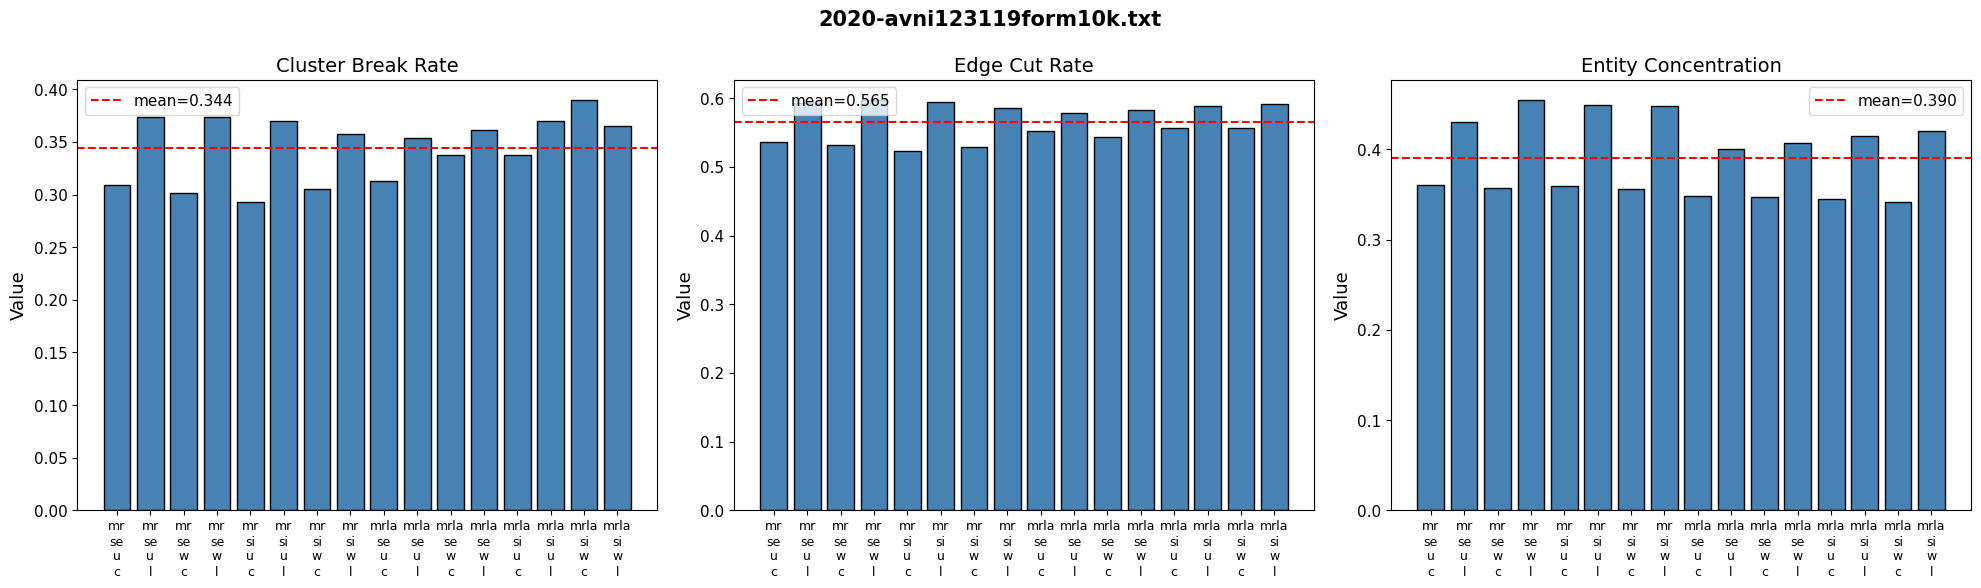

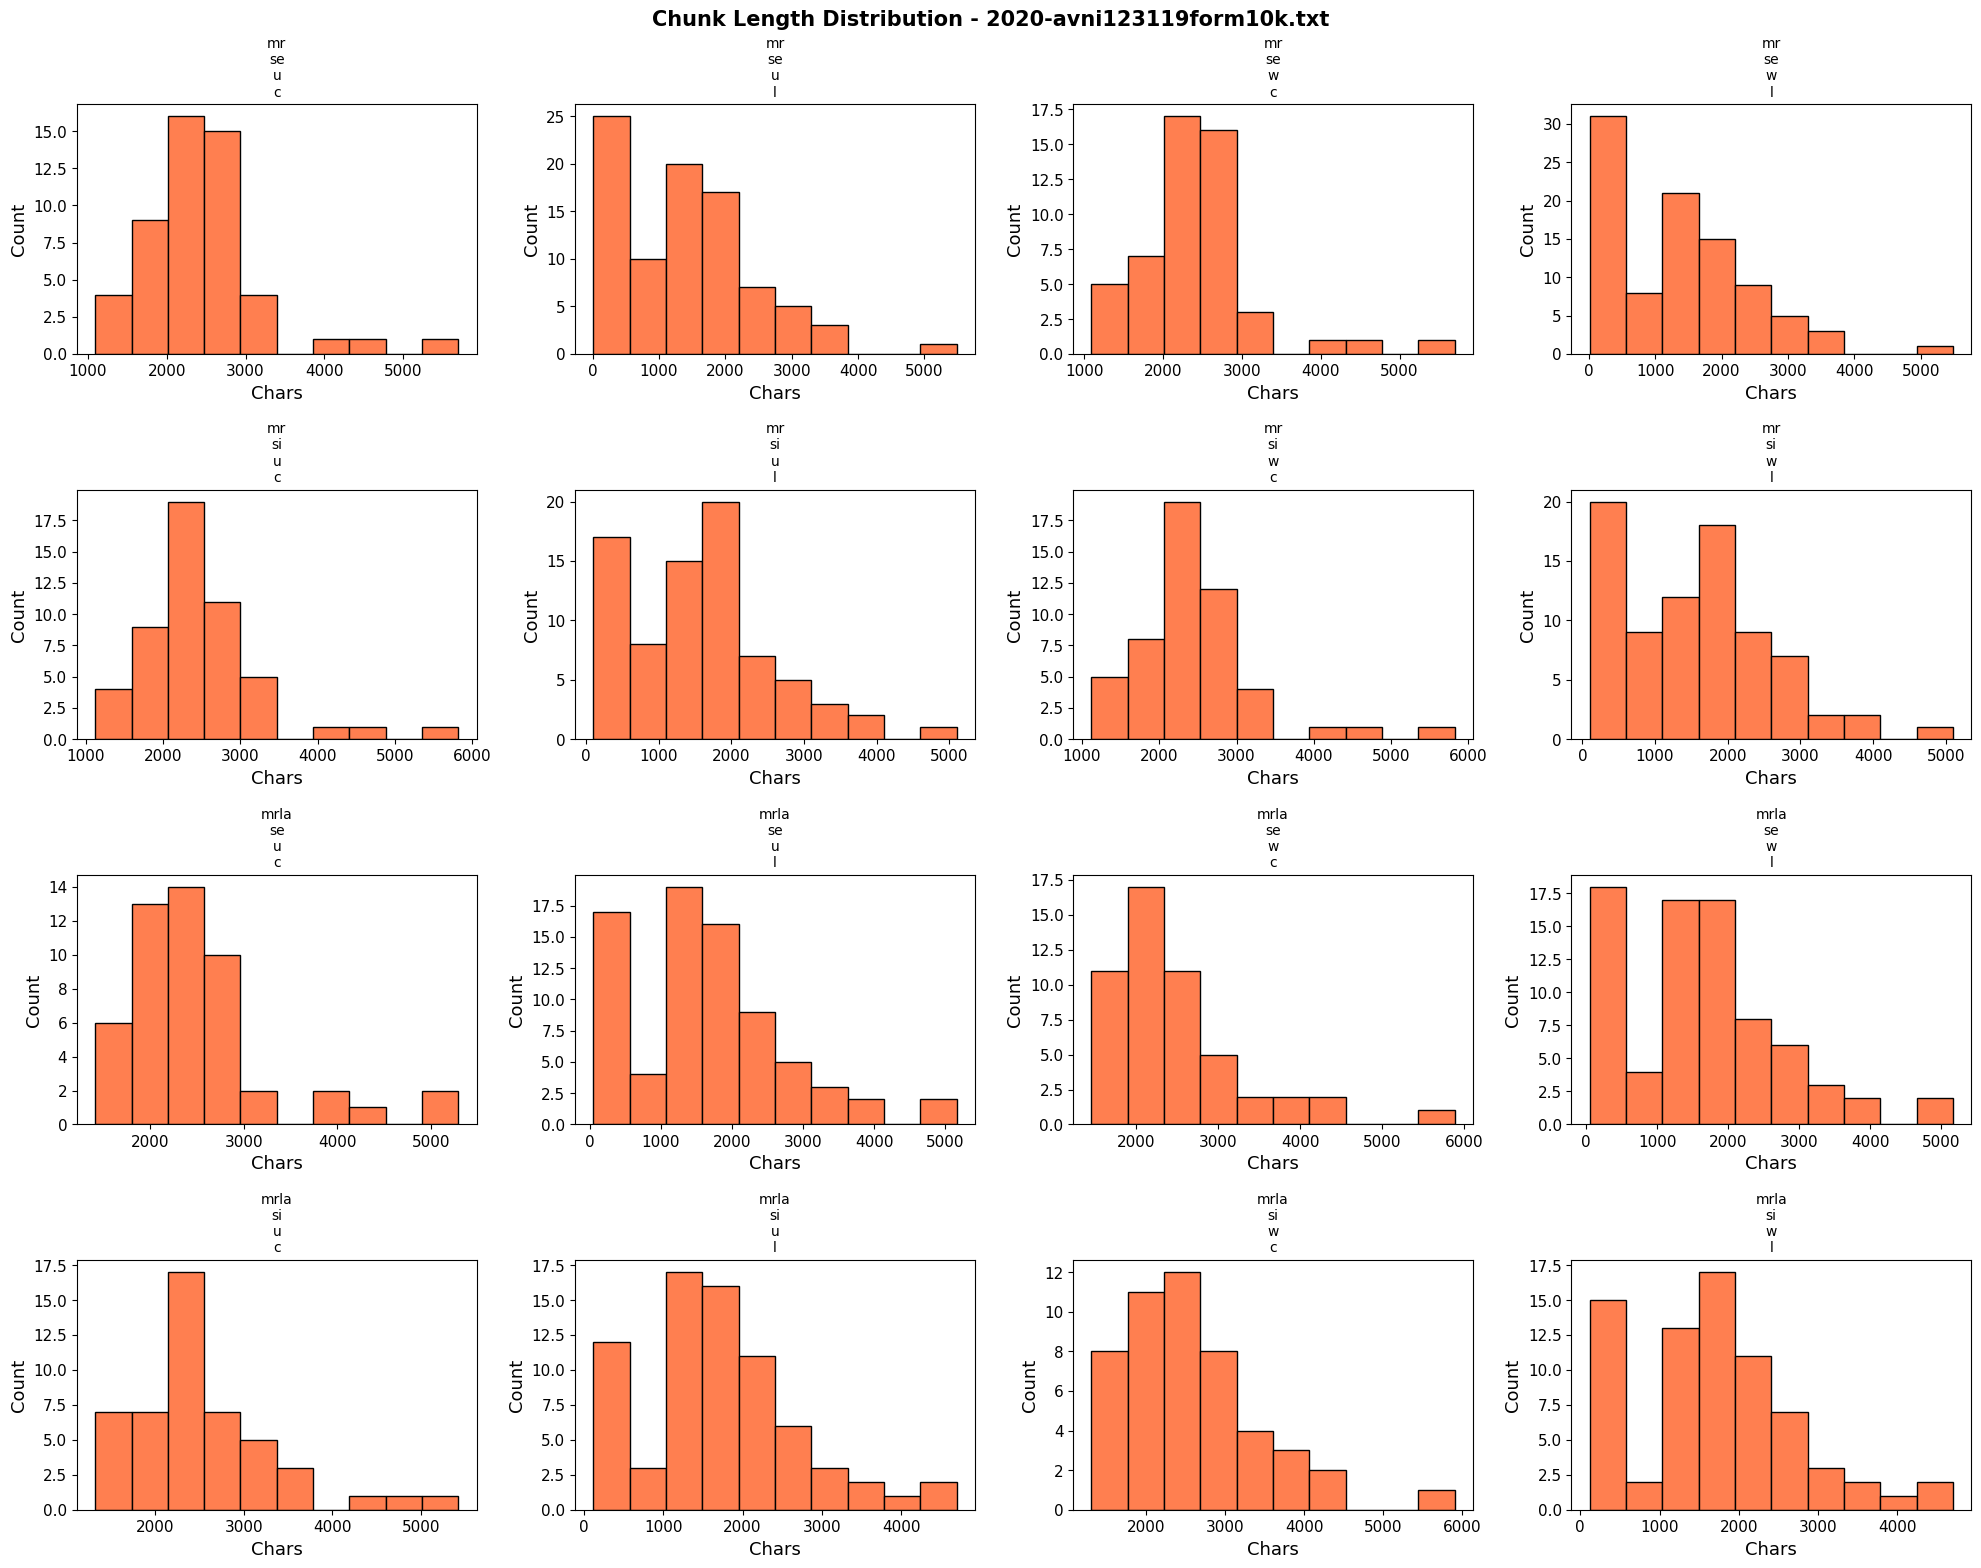

Document : 2020-avni123119form10k.txt
Config   : mr / se / u / c
Chains   : 249   Chunks: 51

  CHUNK 1 of 51
  Entities flagged: E0: 2  E1: 2  E2: 2  E20: 1  E21: 1  E22: 1
10-K 1 avni123119form10k.htm FORM 10-K 
UNITED STATES
SECURITIES AND EXCHANGE COMMISSION
Washington, D.C. 20549
 
FORM 10-K
 
(Mark One)
☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(D) OF [E0|THE SECURITIES EXCHANGE ACT OF 1934]
 
For the fiscal year ended December 31, 2019.
 
☐ TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(D) OF [E0|THE SECURITIES EXCHANGE ACT OF 1934]
For the transition period from _to .
 
Commission file number: 0-30695
 
[E1|ARVANA INC.]
(Exact name of registrant as specified in [E1|its] charter)
 
                               [E20|Nevada]                                                            87-0618509
                  (State or other jurisdiction of                                             (I.R.S. Employer
                   incorporation or organization)                          

In [3]:
_df = load_metrics_for_doc('financial', '2020-avni123119form10k.txt')
display(_df)
plot_histograms(_df, '2020-avni123119form10k.txt')
plot_chunk_lengths('financial', '2020-avni123119form10k.txt')
annotate_document('financial', '2020-avni123119form10k.txt')

In [ ]:
_df = load_metrics_for_doc('financial', '2020-f10k2019_boxscorebrands.txt')
display(_df)
plot_histograms(_df, '2020-f10k2019_boxscorebrands.txt')
plot_chunk_lengths('financial', '2020-f10k2019_boxscorebrands.txt')
annotate_document('financial', '2020-f10k2019_boxscorebrands.txt')

In [ ]:
_df = load_metrics_for_doc('financial', '2020-form10-k.txt')
display(_df)
plot_histograms(_df, '2020-form10-k.txt')
plot_chunk_lengths('financial', '2020-form10-k.txt')
annotate_document('financial', '2020-form10-k.txt')

In [ ]:
_df = load_metrics_for_doc('financial', '2021-avni123120form10k.txt')
display(_df)
plot_histograms(_df, '2021-avni123120form10k.txt')
plot_chunk_lengths('financial', '2021-avni123120form10k.txt')
annotate_document('financial', '2021-avni123120form10k.txt')

In [ ]:
_df = load_metrics_for_doc('financial', '2021-f10k2020_boxscorebrands.txt')
display(_df)
plot_histograms(_df, '2021-f10k2020_boxscorebrands.txt')
plot_chunk_lengths('financial', '2021-f10k2020_boxscorebrands.txt')
annotate_document('financial', '2021-f10k2020_boxscorebrands.txt')

In [ ]:
_df = load_metrics_for_doc('financial', '2021-form10-k.txt')
display(_df)
plot_histograms(_df, '2021-form10-k.txt')
plot_chunk_lengths('financial', '2021-form10-k.txt')
annotate_document('financial', '2021-form10-k.txt')

In [ ]:
_df = load_metrics_for_doc('financial', '2022-aqb-20211231x10k.txt')
display(_df)
plot_histograms(_df, '2022-aqb-20211231x10k.txt')
plot_chunk_lengths('financial', '2022-aqb-20211231x10k.txt')
annotate_document('financial', '2022-aqb-20211231x10k.txt')

In [ ]:
_df = load_metrics_for_doc('financial', '2022-avni123121form10k.txt')
display(_df)
plot_histograms(_df, '2022-avni123121form10k.txt')
plot_chunk_lengths('financial', '2022-avni123121form10k.txt')
annotate_document('financial', '2022-avni123121form10k.txt')

In [ ]:
_df = load_metrics_for_doc('financial', '2022-f10k2021_boxscorebrands.txt')
display(_df)
plot_histograms(_df, '2022-f10k2021_boxscorebrands.txt')
plot_chunk_lengths('financial', '2022-f10k2021_boxscorebrands.txt')
annotate_document('financial', '2022-f10k2021_boxscorebrands.txt')

---
## Paper Documents

,method,sent_incl,weighted,strategy,n_chunks,n_chains,cluster_break_rate,edge_cut_rate,entity_concentration
0,most_recent,full_sentence_excluded,unweighted,conservative,33,96,0.1458,0.2484,0.4548
1,most_recent,full_sentence_excluded,unweighted,liberal,50,96,0.2500,0.3464,0.4914
2,most_recent,full_sentence_excluded,weighted,conservative,33,96,0.1562,0.2614,0.4573
3,most_recent,full_sentence_excluded,weighted,liberal,54,96,0.3125,0.3791,0.5193
4,most_recent,full_sentence_included,unweighted,conservative,31,96,0.1458,0.2484,0.3859
5,most_recent,full_sentence_included,unweighted,liberal,48,96,0.2604,0.3464,0.4914
6,most_recent,full_sentence_included,weighted,conservative,32,96,0.2500,0.3268,0.4495
7,most_recent,full_sentence_included,weighted,liberal,50,96,0.3125,0.3922,0.5200
8,most_recent_low_accessible,full_sentence_excluded,unweighted,conservative,33,96,0.2917,0.3268,0.4036
9,most_recent_low_accessible,full_sentence_excluded,unweighted,liberal,49,96,0.2604,0.3268,0.4603


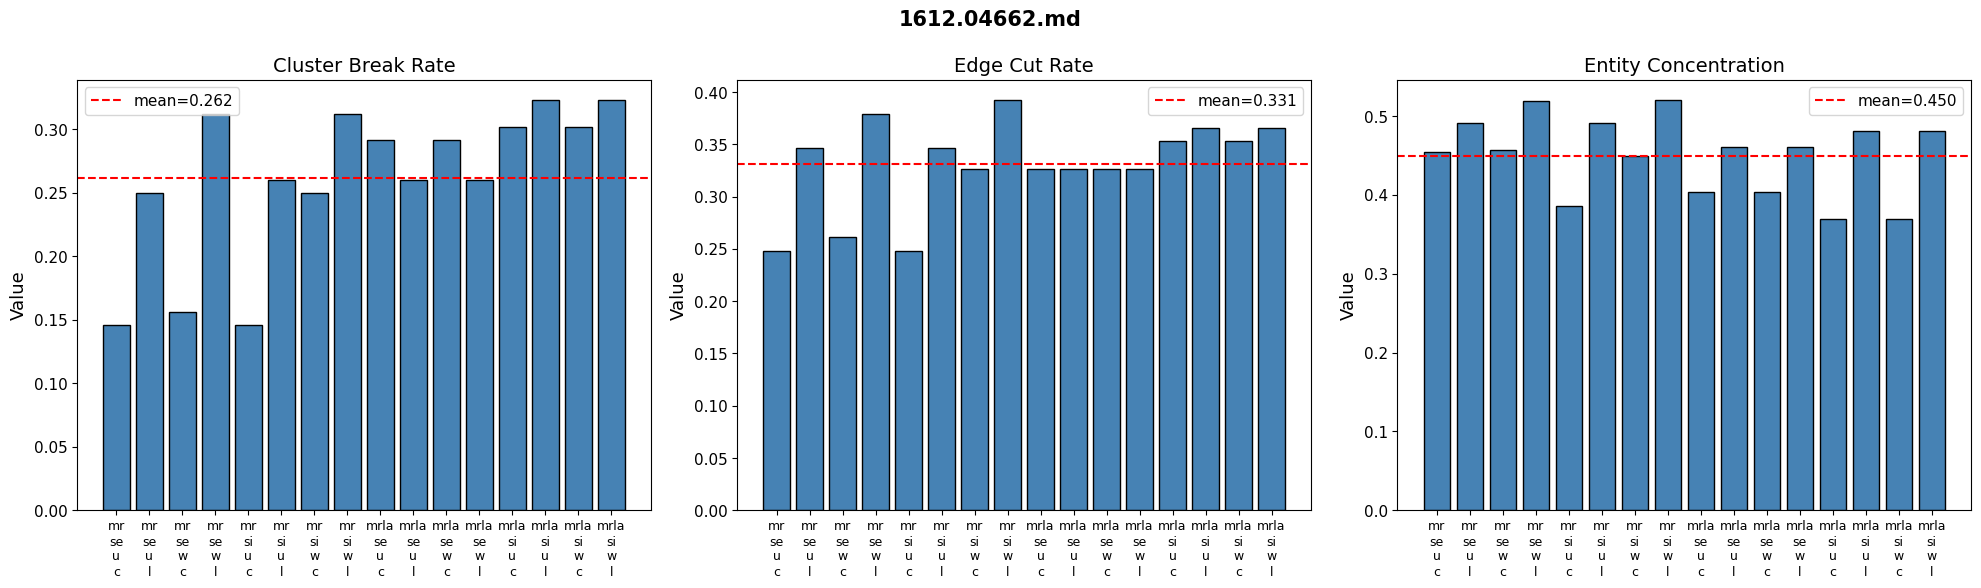

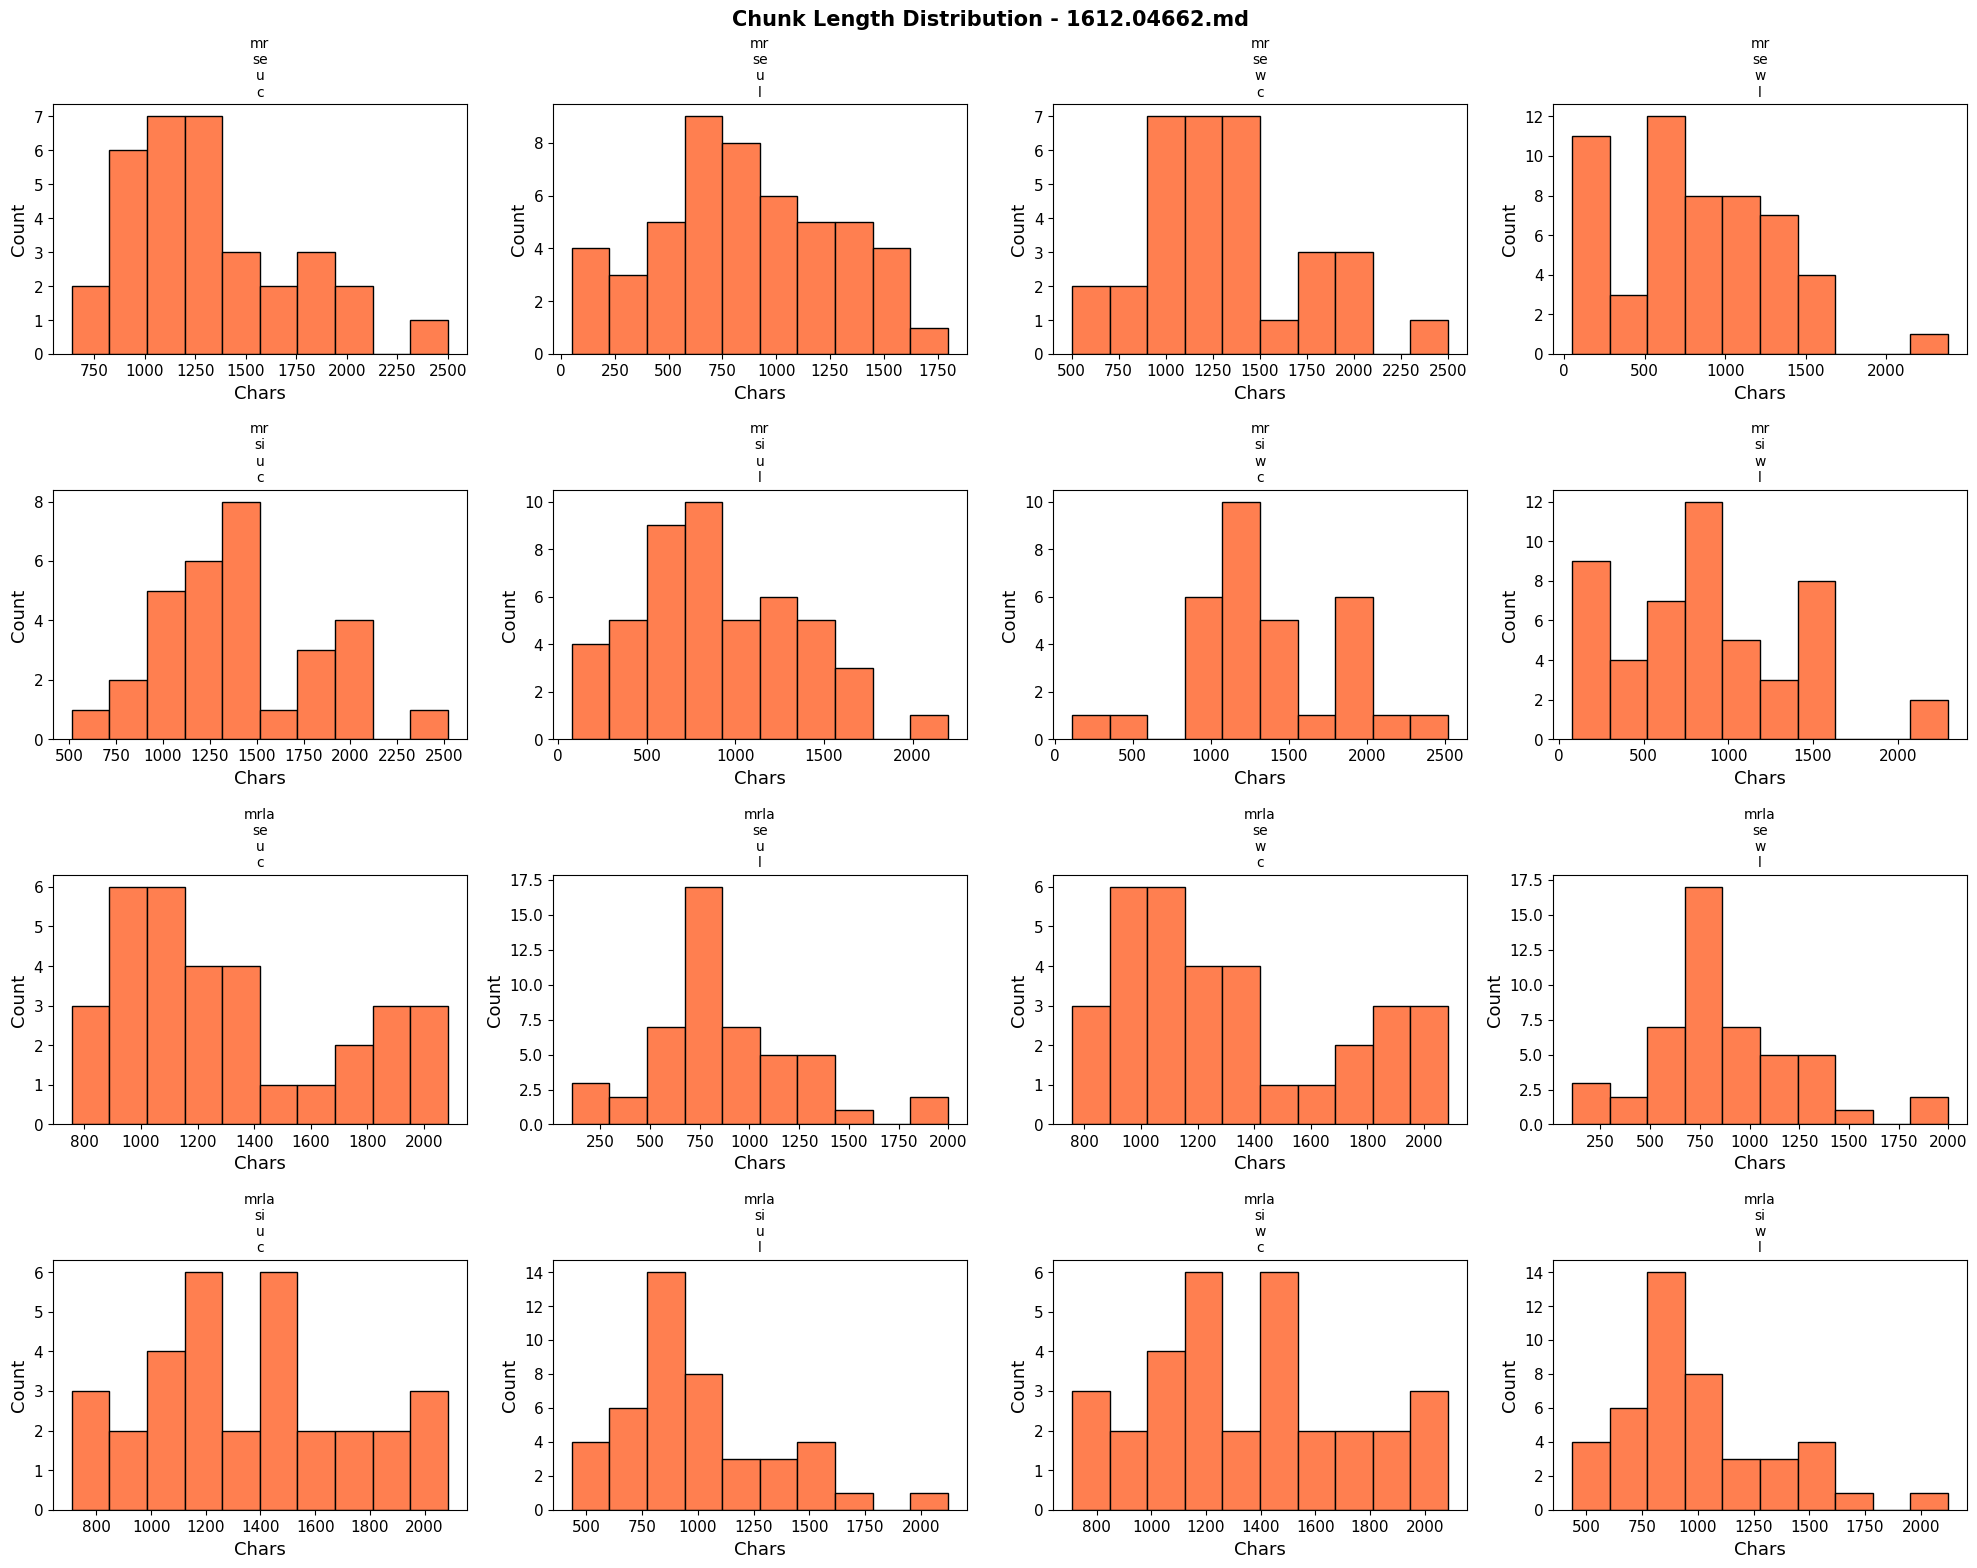

Document : 1612.04662.md
Config   : mr / se / u / c
Chains   : 96   Chunks: 33

  CHUNK 1 of 33
  Entities flagged: E0: 2  E1: 7  E2: 2  E3: 2  E4: 2  E5: 2  E6: 2
# Lightweight compression with encryption based on [E1|Asymmetric Numeral Systems] 

Jarek Duda<br>Jagiellonian University<br>Golebia 24, 31-007 Krakow, [E6|Poland]<br>Email: dudajar@gmail.com


#### Abstract

[E0|Data compression combined with effective encryption] is a common requirement of data storage and transmission. Low cost of [E0|these operations] is often a high priority in order to increase transmission speed and reduce power usage. This requirement is crucial for battery-powered devices with limited resources, such as autonomous remote sensors or implants. Well-known and popular encryption techniques are frequently too expensive. This problem is on the increase as machineto-machine communication and [E4|the Internet of Things] are becoming a reality. Therefore, there is growing demand for finding trade-offs betwe

In [4]:
_df = load_metrics_for_doc('paper', '1612.04662.md')
display(_df)
plot_histograms(_df, '1612.04662.md')
plot_chunk_lengths('paper', '1612.04662.md')
annotate_document('paper', '1612.04662.md')

,method,sent_incl,weighted,strategy,n_chunks,n_chains,cluster_break_rate,edge_cut_rate,entity_concentration
0,most_recent,full_sentence_excluded,unweighted,conservative,20,62,0.1774,0.5026,0.3886
1,most_recent,full_sentence_excluded,unweighted,liberal,33,62,0.2258,0.5538,0.5023
2,most_recent,full_sentence_excluded,weighted,conservative,20,62,0.1774,0.5128,0.3743
3,most_recent,full_sentence_excluded,weighted,liberal,33,62,0.2258,0.5641,0.4918
4,most_recent,full_sentence_included,unweighted,conservative,20,62,0.1935,0.4974,0.4566
5,most_recent,full_sentence_included,unweighted,liberal,30,62,0.2742,0.5538,0.4859
6,most_recent,full_sentence_included,weighted,conservative,20,62,0.1935,0.5128,0.3954
7,most_recent,full_sentence_included,weighted,liberal,30,62,0.2581,0.5590,0.4749
8,most_recent_low_accessible,full_sentence_excluded,unweighted,conservative,21,62,0.2581,0.5744,0.4443
9,most_recent_low_accessible,full_sentence_excluded,unweighted,liberal,35,62,0.3226,0.5744,0.5330


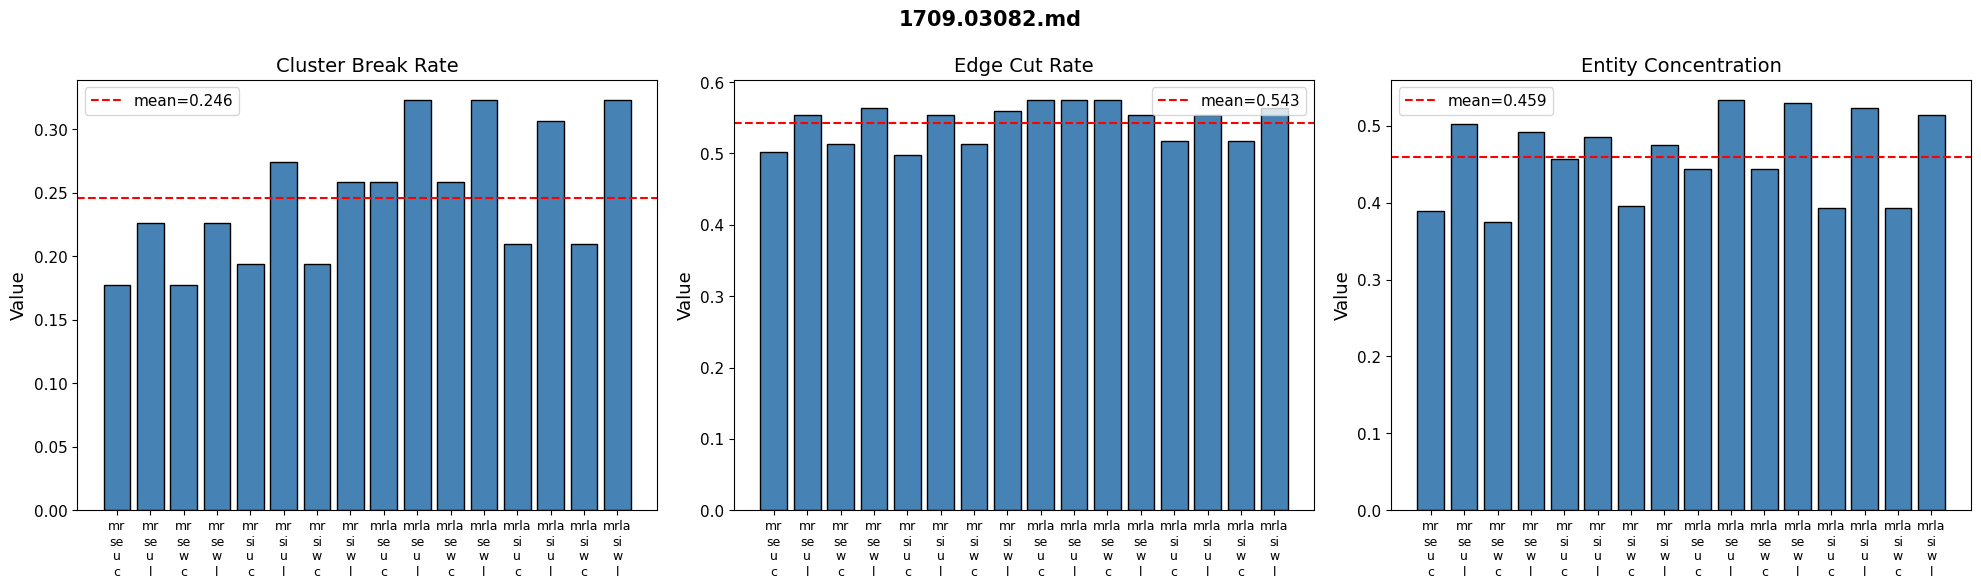

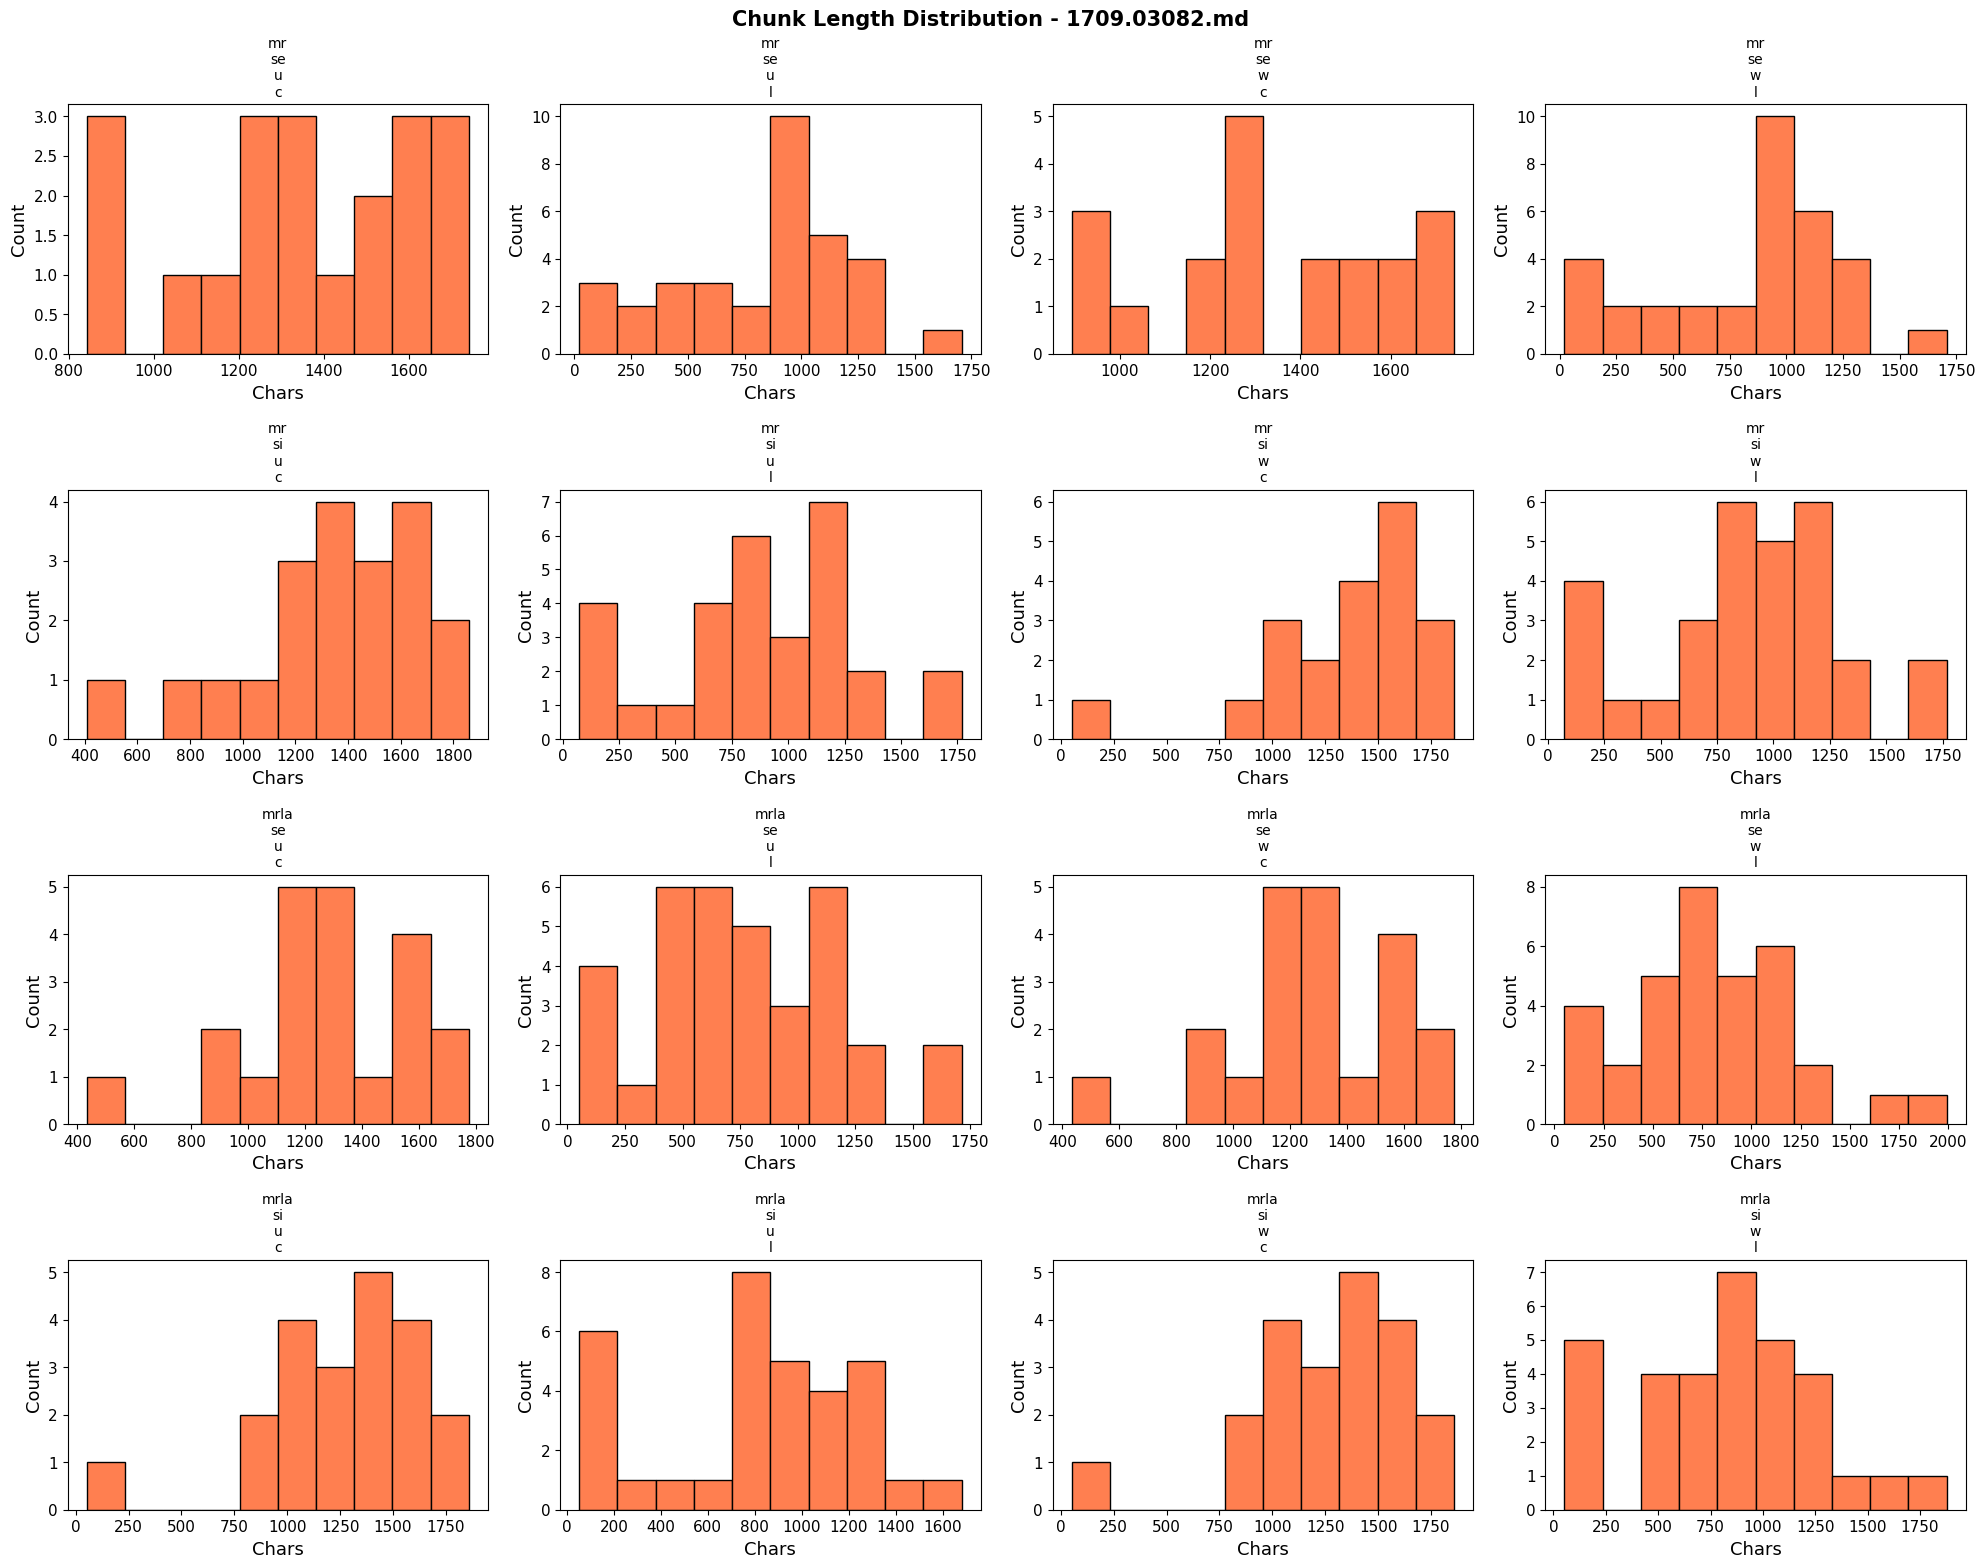

Document : 1709.03082.md
Config   : mr / se / u / c
Chains   : 62   Chunks: 20

  CHUNK 1 of 20
  Entities flagged: E0: 5  E1: 5  E2: 2  E3: 3  E4: 2  E5: 2  E6: 2  E7: 2  E17: 1  E25: 1
# A Neural Network Architecture Combining [E0|Gated Recurrent Unit (GRU)] and Support Vector Machine (SVM) for Intrusion Detection in Network Traffic Data 

Abien Fred M. Agarap<br>abienfred.agarap@gmail.com


#### Abstract[E0|

Gated Recurrent Unit (GRU)] is a recently-developed variation of the long short-term memory (LSTM) unit, both of which are variants of recurrent neural network (RNN). Through empirical evidence, [E1|both models] have been proven to be effective in a wide variety of machine learning tasks such as natural language processing[23], speech recognition[4], and text classification[24]. Conventionally, like most neural networks, [E1|both of the aforementioned RNN variants] [E2|employ] [E3|the Softmax function] as [E1|its] final output layer for [E1|its] prediction, and [E4|the cross-en

In [5]:
_df = load_metrics_for_doc('paper', '1709.03082.md')
display(_df)
plot_histograms(_df, '1709.03082.md')
plot_chunk_lengths('paper', '1709.03082.md')
annotate_document('paper', '1709.03082.md')

,method,sent_incl,weighted,strategy,n_chunks,n_chains,cluster_break_rate,edge_cut_rate,entity_concentration
0,most_recent,full_sentence_excluded,unweighted,conservative,95,312,0.2660,0.4789,0.3649
1,most_recent,full_sentence_excluded,unweighted,liberal,148,312,0.3109,0.5323,0.3790
2,most_recent,full_sentence_excluded,weighted,conservative,93,312,0.2692,0.4752,0.3544
3,most_recent,full_sentence_excluded,weighted,liberal,148,312,0.3109,0.5248,0.4021
4,most_recent,full_sentence_included,unweighted,conservative,88,312,0.2949,0.4913,0.3194
5,most_recent,full_sentence_included,unweighted,liberal,133,312,0.3301,0.5347,0.3581
6,most_recent,full_sentence_included,weighted,conservative,88,312,0.2917,0.4851,0.3233
7,most_recent,full_sentence_included,weighted,liberal,133,312,0.3173,0.5261,0.3593
8,most_recent_low_accessible,full_sentence_excluded,unweighted,conservative,93,312,0.3301,0.5285,0.3239
9,most_recent_low_accessible,full_sentence_excluded,unweighted,liberal,135,312,0.3846,0.5819,0.3769


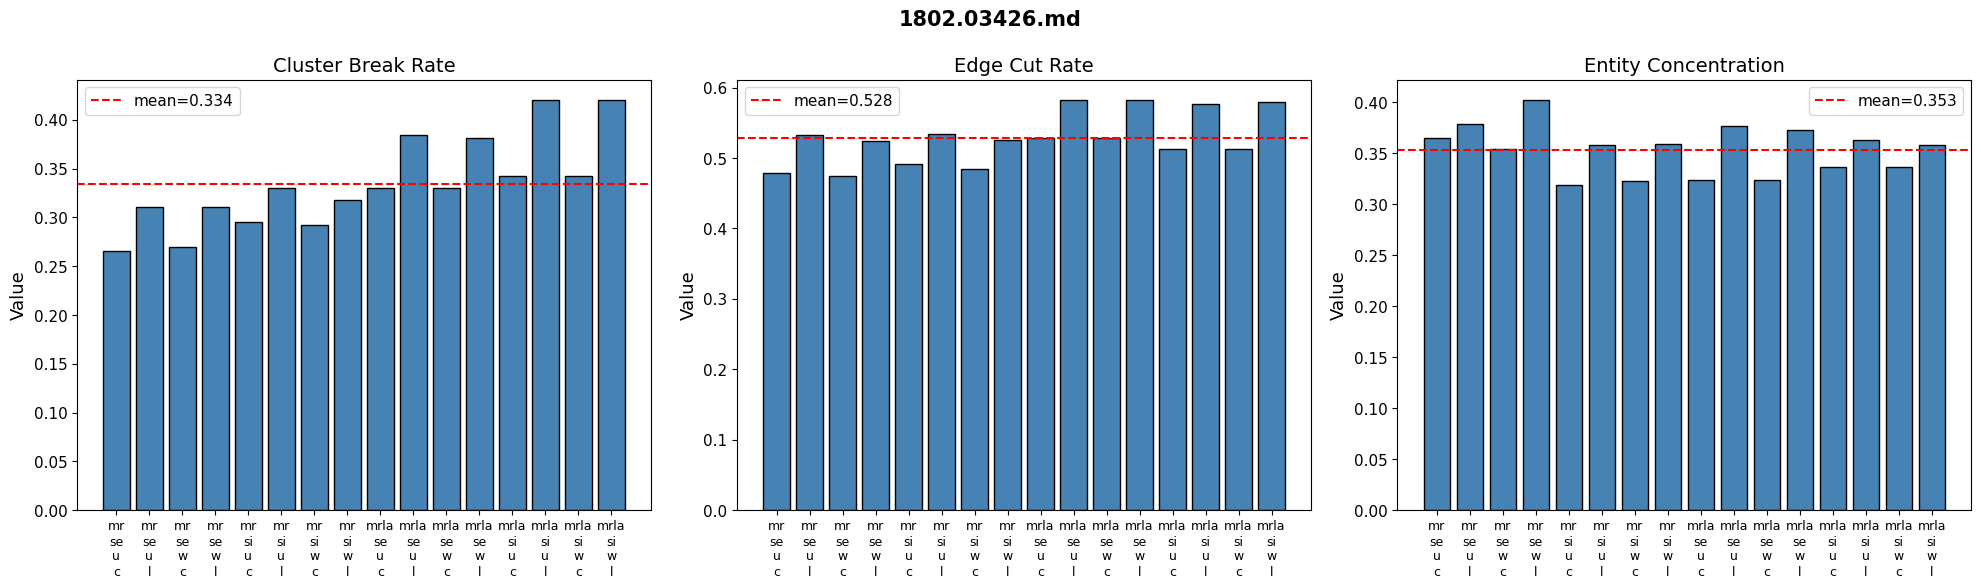

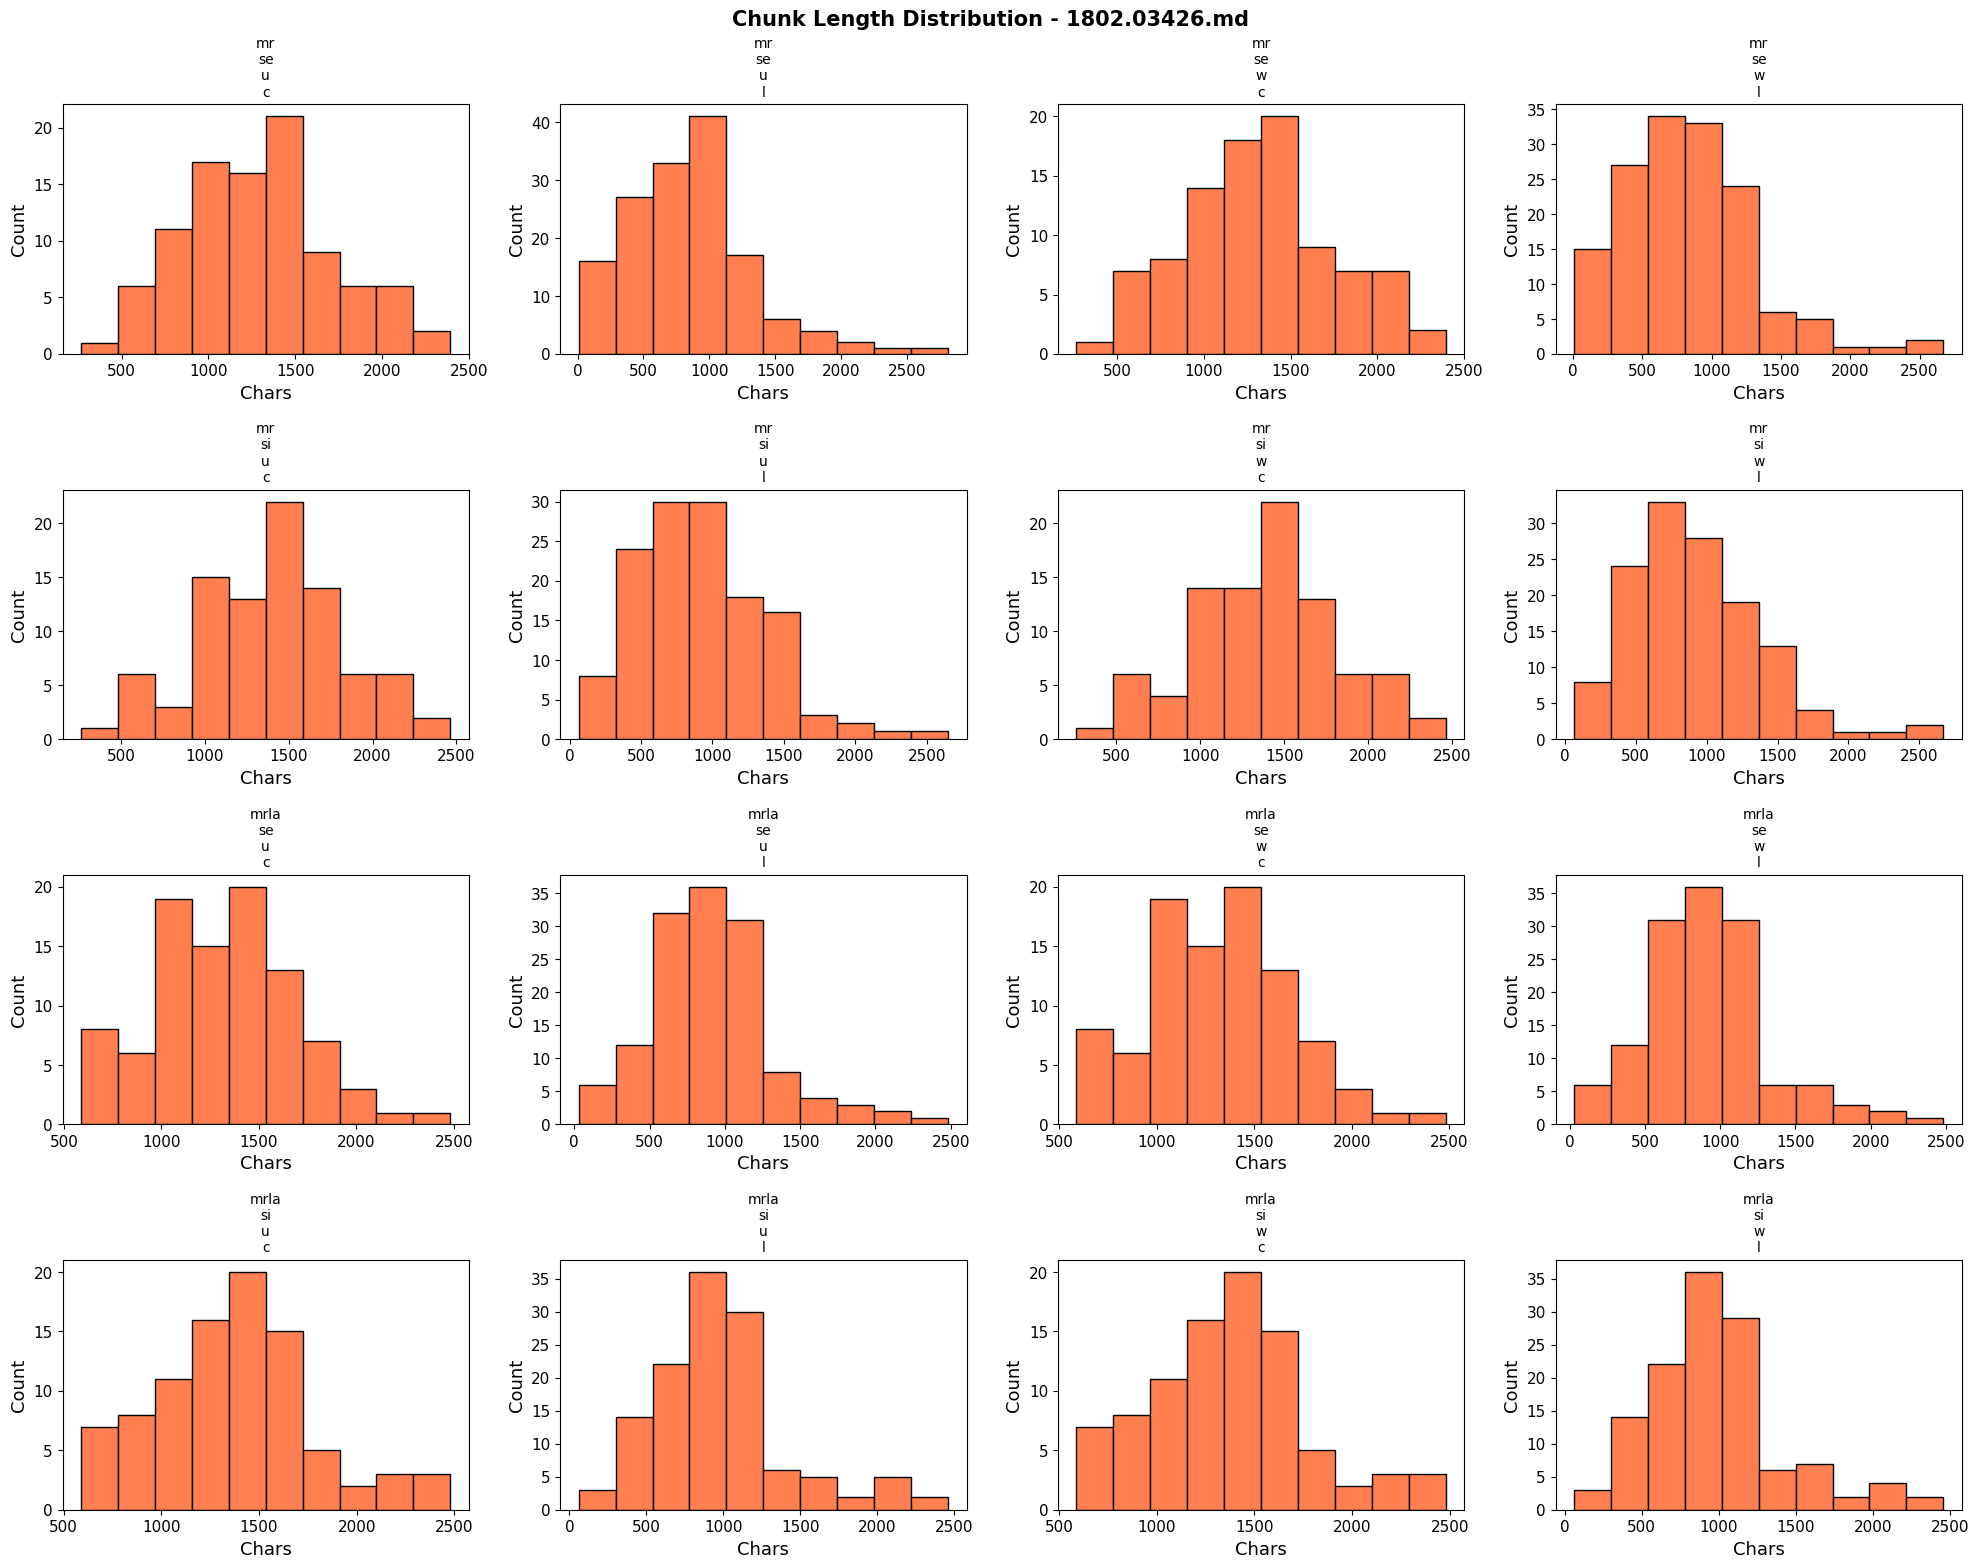

Document : 1802.03426.md
Config   : mr / se / u / c
Chains   : 312   Chunks: 95

  CHUNK 1 of 95
  Entities flagged: E0: 2  E1: 5  E5: 1
# [E1|UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction] 

Leland McInnes<br>[E0|Tutte Institute for Mathematics and Computing]<br>leland.mcinnes@gmail.com<br>John Healy<br>[E0|Tutte Institute for Mathematics and Computing]<br>jchealy@gmail.com<br>James Melville<br>jlmelville@gmail.com

September 21,2020


#### Abstract

UMAP (Uniform Manifold Approximation and Projection) is a novel manifold learning technique for dimension reduction. [E1|UMAP] is constructed from a theoretical framework based in Riemannian geometry and algebraic topology. The result is a practical scalable algorithm that is applicable to real world data. The [E1|UMAP] algorithm is competitive with [E5|t-SNE] for visualization quality, and arguably preserves more of the global structure with superior run time performance. Furthermore, [E1|UMAP] has no comput

In [6]:
_df = load_metrics_for_doc('paper', '1802.03426.md')
display(_df)
plot_histograms(_df, '1802.03426.md')
plot_chunk_lengths('paper', '1802.03426.md')
annotate_document('paper', '1802.03426.md')

In [ ]:
_df = load_metrics_for_doc('paper', '1802.08129.md')
display(_df)
plot_histograms(_df, '1802.08129.md')
plot_chunk_lengths('paper', '1802.08129.md')
annotate_document('paper', '1802.08129.md')

In [ ]:
_df = load_metrics_for_doc('paper', '1803.08375.md')
display(_df)
plot_histograms(_df, '1803.08375.md')
plot_chunk_lengths('paper', '1803.08375.md')
annotate_document('paper', '1803.08375.md')

In [ ]:
_df = load_metrics_for_doc('paper', '2405.20774.md')
display(_df)
plot_histograms(_df, '2405.20774.md')
plot_chunk_lengths('paper', '2405.20774.md')
annotate_document('paper', '2405.20774.md')

In [ ]:
_df = load_metrics_for_doc('paper', '2405.20974.md')
display(_df)
plot_histograms(_df, '2405.20974.md')
plot_chunk_lengths('paper', '2405.20974.md')
annotate_document('paper', '2405.20974.md')

In [ ]:
_df = load_metrics_for_doc('paper', '2405.21018.md')
display(_df)
plot_histograms(_df, '2405.21018.md')
plot_chunk_lengths('paper', '2405.21018.md')
annotate_document('paper', '2405.21018.md')

In [ ]:
_df = load_metrics_for_doc('paper', '2405.21040.md')
display(_df)
plot_histograms(_df, '2405.21040.md')
plot_chunk_lengths('paper', '2405.21040.md')
annotate_document('paper', '2405.21040.md')

In [ ]:
_df = load_metrics_for_doc('paper', '2405.21046.md')
display(_df)
plot_histograms(_df, '2405.21046.md')
plot_chunk_lengths('paper', '2405.21046.md')
annotate_document('paper', '2405.21046.md')

---
## Baseline vs. Coreference Comparison
Static 300-char `RecursiveCharacterTextSplitter` baseline compared to the mean across all 16 coreference configs. Run `generate_baseline_chunks.py` first.

### Financial Documents

--- Baseline ---


,method,chunk_size_chars,chunk_overlap_chars,n_chunks,n_chains,cluster_break_rate,edge_cut_rate,entity_concentration
0,recursive_character,300,25,602,249,0.7269,0.8520,0.4643


--- Coreference (all configs) ---


,cluster_break_rate,edge_cut_rate,entity_concentration,method,sent_incl,weighted,strategy
0,0.2972,0.5298,0.3919,most_recent,full_sentence_excluded,unweighted,conservative
1,0.3373,0.5847,0.4902,most_recent,full_sentence_excluded,unweighted,liberal
2,0.2892,0.5475,0.3832,most_recent,full_sentence_excluded,weighted,conservative
3,0.3213,0.5782,0.4899,most_recent,full_sentence_excluded,weighted,liberal
4,0.2811,0.5363,0.3773,most_recent,full_sentence_included,unweighted,conservative
5,0.3333,0.5726,0.4812,most_recent,full_sentence_included,unweighted,liberal
6,0.3133,0.5475,0.3849,most_recent,full_sentence_included,weighted,conservative
7,0.3454,0.5652,0.4939,most_recent,full_sentence_included,weighted,liberal
8,0.3414,0.5531,0.3682,most_recent_low_accessible,full_sentence_excluded,unweighted,conservative
9,0.4016,0.6034,0.4218,most_recent_low_accessible,full_sentence_excluded,unweighted,liberal


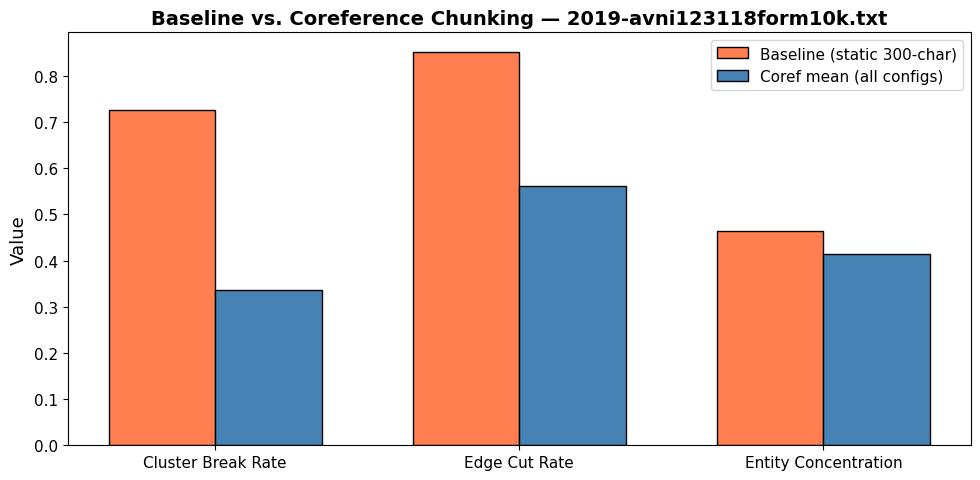

In [9]:
_base = load_baseline_metrics_for_doc('financial', '2019-avni123118form10k.txt')
_coref = load_metrics_for_doc('financial', '2019-avni123118form10k.txt')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '2019-avni123118form10k.txt')

--- Baseline ---


,method,chunk_size_chars,chunk_overlap_chars,n_chunks,n_chains,cluster_break_rate,edge_cut_rate,entity_concentration
0,recursive_character,300,25,612,249,0.7349,0.8581,0.4573


--- Coreference (all configs) ---


,cluster_break_rate,edge_cut_rate,entity_concentration,method,sent_incl,weighted,strategy
0,0.3092,0.5357,0.3601,most_recent,full_sentence_excluded,unweighted,conservative
1,0.3735,0.5925,0.4310,most_recent,full_sentence_excluded,unweighted,liberal
2,0.3012,0.5321,0.3571,most_recent,full_sentence_excluded,weighted,conservative
3,0.3735,0.5971,0.4545,most_recent,full_sentence_excluded,weighted,liberal
4,0.2932,0.5229,0.3595,most_recent,full_sentence_included,unweighted,conservative
5,0.3695,0.5952,0.4494,most_recent,full_sentence_included,unweighted,liberal
6,0.3052,0.5293,0.3559,most_recent,full_sentence_included,weighted,conservative
7,0.3574,0.5861,0.4481,most_recent,full_sentence_included,weighted,liberal
8,0.3133,0.5522,0.3482,most_recent_low_accessible,full_sentence_excluded,unweighted,conservative
9,0.3534,0.5788,0.4005,most_recent_low_accessible,full_sentence_excluded,unweighted,liberal


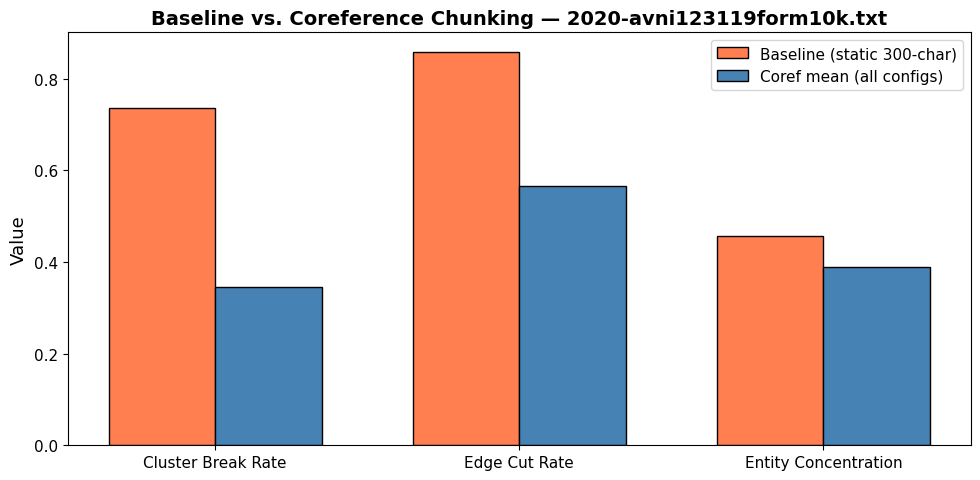

In [10]:
_base = load_baseline_metrics_for_doc('financial', '2020-avni123119form10k.txt')
_coref = load_metrics_for_doc('financial', '2020-avni123119form10k.txt')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '2020-avni123119form10k.txt')

--- Baseline ---


,method,chunk_size_chars,chunk_overlap_chars,n_chunks,n_chains,cluster_break_rate,edge_cut_rate,entity_concentration
0,recursive_character,300,25,1057,430,0.7023,0.8637,0.4515


--- Coreference (all configs) ---


,cluster_break_rate,edge_cut_rate,entity_concentration,method,sent_incl,weighted,strategy
0,0.2767,0.5787,0.4263,most_recent,full_sentence_excluded,unweighted,conservative
1,0.3628,0.6262,0.4946,most_recent,full_sentence_excluded,unweighted,liberal
2,0.3116,0.5830,0.4023,most_recent,full_sentence_excluded,weighted,conservative
3,0.3535,0.6228,0.5005,most_recent,full_sentence_excluded,weighted,liberal
4,0.3233,0.5912,0.4171,most_recent,full_sentence_included,unweighted,conservative
5,0.3837,0.6329,0.4386,most_recent,full_sentence_included,unweighted,liberal
6,0.3140,0.5936,0.4098,most_recent,full_sentence_included,weighted,conservative
7,0.3814,0.6286,0.4370,most_recent,full_sentence_included,weighted,liberal
8,0.3209,0.5873,0.3963,most_recent_low_accessible,full_sentence_excluded,unweighted,conservative
9,0.4163,0.6512,0.4216,most_recent_low_accessible,full_sentence_excluded,unweighted,liberal


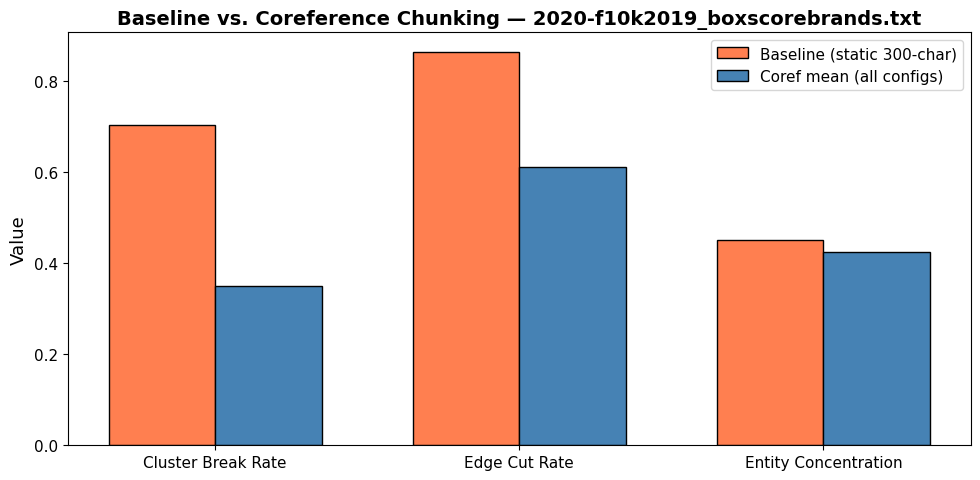

In [11]:
_base = load_baseline_metrics_for_doc('financial', '2020-f10k2019_boxscorebrands.txt')
_coref = load_metrics_for_doc('financial', '2020-f10k2019_boxscorebrands.txt')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '2020-f10k2019_boxscorebrands.txt')

--- Baseline ---


,method,chunk_size_chars,chunk_overlap_chars,n_chunks,n_chains,cluster_break_rate,edge_cut_rate,entity_concentration
0,recursive_character,300,25,783,351,0.6895,0.7913,0.3975


--- Coreference (all configs) ---


,cluster_break_rate,edge_cut_rate,entity_concentration,method,sent_incl,weighted,strategy
0,0.2051,0.4619,0.3457,most_recent,full_sentence_excluded,unweighted,conservative
1,0.3305,0.5388,0.4166,most_recent,full_sentence_excluded,unweighted,liberal
2,0.2336,0.4882,0.3447,most_recent,full_sentence_excluded,weighted,conservative
3,0.3105,0.5270,0.4304,most_recent,full_sentence_excluded,weighted,liberal
4,0.2336,0.4639,0.3456,most_recent,full_sentence_included,unweighted,conservative
5,0.3219,0.5361,0.4242,most_recent,full_sentence_included,unweighted,liberal
6,0.2279,0.4674,0.3455,most_recent,full_sentence_included,weighted,conservative
7,0.3077,0.5298,0.4300,most_recent,full_sentence_included,weighted,liberal
8,0.2792,0.4882,0.3529,most_recent_low_accessible,full_sentence_excluded,unweighted,conservative
9,0.3504,0.5583,0.4129,most_recent_low_accessible,full_sentence_excluded,unweighted,liberal


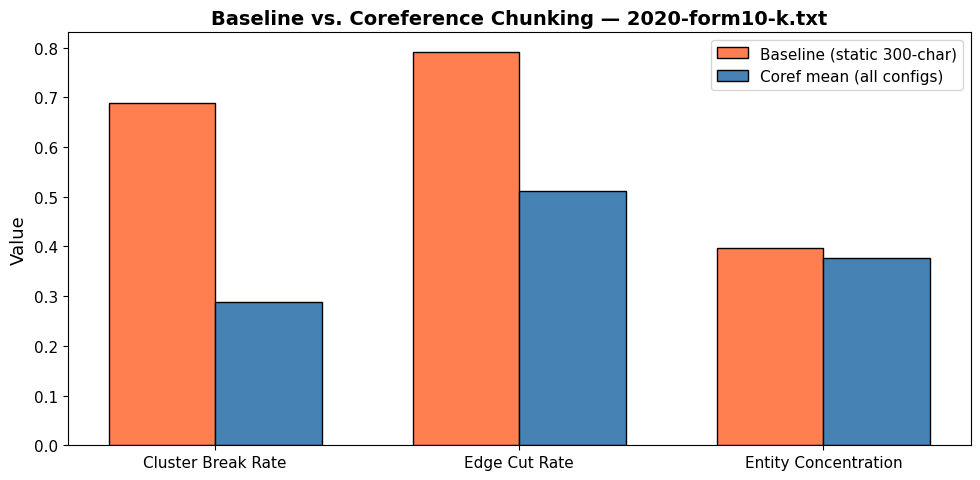

In [12]:
_base = load_baseline_metrics_for_doc('financial', '2020-form10-k.txt')
_coref = load_metrics_for_doc('financial', '2020-form10-k.txt')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '2020-form10-k.txt')

In [ ]:
_base = load_baseline_metrics_for_doc('financial', '2021-avni123120form10k.txt')
_coref = load_metrics_for_doc('financial', '2021-avni123120form10k.txt')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '2021-avni123120form10k.txt')

In [ ]:
_base = load_baseline_metrics_for_doc('financial', '2021-f10k2020_boxscorebrands.txt')
_coref = load_metrics_for_doc('financial', '2021-f10k2020_boxscorebrands.txt')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '2021-f10k2020_boxscorebrands.txt')

In [ ]:
_base = load_baseline_metrics_for_doc('financial', '2021-form10-k.txt')
_coref = load_metrics_for_doc('financial', '2021-form10-k.txt')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '2021-form10-k.txt')

In [ ]:
_base = load_baseline_metrics_for_doc('financial', '2022-aqb-20211231x10k.txt')
_coref = load_metrics_for_doc('financial', '2022-aqb-20211231x10k.txt')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '2022-aqb-20211231x10k.txt')

In [ ]:
_base = load_baseline_metrics_for_doc('financial', '2022-avni123121form10k.txt')
_coref = load_metrics_for_doc('financial', '2022-avni123121form10k.txt')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '2022-avni123121form10k.txt')

In [ ]:
_base = load_baseline_metrics_for_doc('financial', '2022-f10k2021_boxscorebrands.txt')
_coref = load_metrics_for_doc('financial', '2022-f10k2021_boxscorebrands.txt')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '2022-f10k2021_boxscorebrands.txt')

### Paper Documents

In [ ]:
_base = load_baseline_metrics_for_doc('paper', '1612.04662.md')
_coref = load_metrics_for_doc('paper', '1612.04662.md')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '1612.04662.md')

In [ ]:
_base = load_baseline_metrics_for_doc('paper', '1709.03082.md')
_coref = load_metrics_for_doc('paper', '1709.03082.md')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '1709.03082.md')

In [ ]:
_base = load_baseline_metrics_for_doc('paper', '1802.03426.md')
_coref = load_metrics_for_doc('paper', '1802.03426.md')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '1802.03426.md')

In [ ]:
_base = load_baseline_metrics_for_doc('paper', '1802.08129.md')
_coref = load_metrics_for_doc('paper', '1802.08129.md')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '1802.08129.md')

In [ ]:
_base = load_baseline_metrics_for_doc('paper', '1803.08375.md')
_coref = load_metrics_for_doc('paper', '1803.08375.md')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '1803.08375.md')

In [ ]:
_base = load_baseline_metrics_for_doc('paper', '2405.20774.md')
_coref = load_metrics_for_doc('paper', '2405.20774.md')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '2405.20774.md')

In [ ]:
_base = load_baseline_metrics_for_doc('paper', '2405.20974.md')
_coref = load_metrics_for_doc('paper', '2405.20974.md')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '2405.20974.md')

In [ ]:
_base = load_baseline_metrics_for_doc('paper', '2405.21018.md')
_coref = load_metrics_for_doc('paper', '2405.21018.md')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '2405.21018.md')

In [ ]:
_base = load_baseline_metrics_for_doc('paper', '2405.21040.md')
_coref = load_metrics_for_doc('paper', '2405.21040.md')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '2405.21040.md')

In [ ]:
_base = load_baseline_metrics_for_doc('paper', '2405.21046.md')
_coref = load_metrics_for_doc('paper', '2405.21046.md')
print('--- Baseline ---')
display(_base)
print('--- Coreference (all configs) ---')
display(_coref[METRICS + ['method','sent_incl','weighted','strategy']].round(4))
plot_baseline_vs_coref(_base, _coref, '2405.21046.md')